# Integrated energy grids - Multi-country

## Imports

In [2]:
# Imports
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
from datetime import timedelta
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import sys
import importlib
from IPython.display import display

pd.options.display.width = 120

print('pandas', pd.__version__, 'numpy', np.__version__)

pandas 3.0.2 numpy 2.4.3


## Data collection

### Folder Setup

In [3]:
# List files in current directory
print("Current directory:", os.getcwd())
print("\nFiles in workspace:")
for file in os.listdir('.'):
    print(f"  {file}")

Current directory: d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment

Files in workspace:
  .git
  python_codes
  IEG_Course_Project_Part1.pdf
  Data
  Plots
  README.md
  back-up projects
  IEG_Assignment_Multi_country.ipynb
  IEG_Assignment_Single_country.ipynb
  IEG_Course_Project_Part2.pdf
  IEG_Interannual_Variability.ipynb
  IEG_Electricity_H2_network.ipynb


### CSV loading

- **Installed Capacity**
- **Hourly operating program**
- **Daily gas price**

In [4]:
# --- 1) Load CSV data (workspace files) ---
base = Path('./Data')
cap_file = base / 'export_InstalledCapacityGenerationTotal_2026-03-03_17_12.csv'
hourly_file = base / 'export_OperatingHourlyProgramGeneration+Storage+BalearicHVDCLinkP48_2026-03-03_17_22.csv'
gas_file = base / 'Gas prices Spain 2025.csv'

# Read installed capacities
cap_df = pd.read_csv(cap_file, sep=';')
cap_df = cap_df.rename(columns={'name':'tech','value':'capacity','start_date':'start','end_date':'end'})
print('installed capacities rows:', len(cap_df))
display(cap_df.head())

# Read hourly operating program (we treat 'value' as system demand/required generation)
hourly_df = pd.read_csv(hourly_file, sep=';')
hourly_df['datetime'] = pd.to_datetime(hourly_df['datetime'], utc=True)
hourly_df = hourly_df.set_index('datetime').sort_index()
print('hourly rows:', len(hourly_df))
display(hourly_df.head(3))

# Read gas price (daily)
gas_df = pd.read_csv(gas_file, sep=';', header=0)
# Clean up columns and decimals
gas_df.columns = [c.strip('"') for c in gas_df.columns]
gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)
gas_df['MIBGAS-ES Index'] = gas_df['MIBGAS-ES Index'].astype(str).str.replace(',', '.').astype(float)
gas_df = gas_df.set_index('Delivery Day')['MIBGAS-ES Index']
display(gas_df.head(3))

installed capacities rows: 27


,id,tech,geoid,geoname,capacity,start,end
0,1478,Installed capacity generation coal,NaN,NaN,241.200,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
1,1478,Installed capacity generation coal,NaN,NaN,570.050,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
2,1478,Installed capacity generation coal,NaN,NaN,1249.925,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
3,1483,Installed capacity generation combined cycle GT,NaN,NaN,26250.145,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
4,1489,Installed capacity generation cogeneration,NaN,NaN,5622.455,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00


hourly rows: 188498


,id,name,geoid,geoname,value
datetime,,,,,
2023-12-31 23:00:00+00:00,10024,Operating Hourly Program Generation + storage ...,NaN,NaN,21453.375
2023-12-31 23:00:00+00:00,92,Operating Hourly Program P48 Biogas,NaN,NaN,82.500
2023-12-31 23:00:00+00:00,91,Operating Hourly Program P48 Biomass,NaN,NaN,207.600


C:\Users\ccano\AppData\Local\Temp\ipykernel_4268\2052013660.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)


Delivery Day
2025-03-03    46.23
2025-03-04    44.69
2025-03-05    43.07
Name: MIBGAS-ES Index, dtype: float64

**Compilation of installed capacity**

In [5]:
# --- 2) Compile capacities by technology ---
cap_by_tech = cap_df.groupby('tech', dropna=False)['capacity'].sum().to_frame()
# Map long names to short technology keys (edit mapping as needed)
tech_map = {
    'Installed capacity generation combined cycle GT': 'CCGT',
    'Installed capacity generation coal': 'Coal',
    'Installed capacity generation nuclear': 'Nuclear',
    'Installed capacity generation wind': 'Wind',
    'Installed capacity generation hydro': 'Hydro',
    'Installed capacity generation solar': 'Solar',
    'Installed capacity generation solar PV': 'Solar',
    'Installed capacity generation solar thermal': 'Solar',
    'Installed capacity generation diesel engines': 'Diesel',
    'Installed capacity generation cogeneration': 'CHP',
    'Installed capacity generation other renewables': 'OtherRenew'
}
tech_caps = {}
for longname, cap in cap_by_tech['capacity'].items():
    key = tech_map.get(longname, longname)
    tech_caps[key] = tech_caps.get(key, 0.0) + float(cap)

# Filter to only Wind, Solar, and Hydro
tech_caps = {k: v for k, v in tech_caps.items() if k in ['Wind', 'Solar', 'Hydro']}
tech_caps = pd.Series(tech_caps).sort_values(ascending=False)
print('Aggregated technology capacities (MW):')
display(tech_caps)

Aggregated technology capacities (MW):


Solar    33947.119
Wind     31020.198
Hydro    17096.959
dtype: float64

**Hourly Demand Set-up**

In [6]:
# --- 3) Prepare hourly demand and hourly gas price series ---
demand = hourly_df['value'].rename('demand')
# Expand daily gas price to hourly (forward-fill)
# build hourly index covering demand range
hour_index = pd.date_range(start=demand.index[0].floor('D'), end=demand.index[-1].ceil('D') - timedelta(hours=1), freq='h')
print('demand range:', demand.index.min(), 'to', demand.index.max())
display(demand.head())

demand range: 2023-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00


datetime
2023-12-31 23:00:00+00:00    21453.375
2023-12-31 23:00:00+00:00       82.500
2023-12-31 23:00:00+00:00      207.600
2023-12-31 23:00:00+00:00        2.800
2023-12-31 23:00:00+00:00     3341.100
Name: demand, dtype: float64

**Generation by technology dataframe creation**

In [7]:
# Read full hourly file (raw multiple technologies)
df_raw = pd.read_csv(hourly_file, sep=';')
# parse datetimes
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], utc=True)

# helper to simplify long technology names
def simplify_name(n: str) -> str:
    # handle NaN or non-string
    if pd.isna(n):
        return 'Other'
    s = str(n).lower().strip()
    if not s:
        return 'Other'
    # Remove common prefixes/words that add noise
    for drop in ['operating hourly program', 'operating hourly program generation', 'operating hourly program p48', 'operating hourly program p48 ', 'p48', 'balearic', 'hvdc link', '+', '/', '\\n']:
        s = s.replace(drop, ' ')
    s = ' '.join(s.split())
    # mapping by keywords
    if 'hydro' in s:
        return 'Hydro'
    if 'wind' in s:
        return 'Wind'
    if 'solar' in s or 'pv' in s:
        return 'Solar'
    if 'coal' in s:
        return 'Coal'
    if 'nuclear' in s:
        return 'Nuclear'
    if 'combined cycle' in s or 'ccgt' in s or 'combined' in s:
        return 'CCGT'
    if 'diesel' in s or 'diesel engines' in s:
        return 'Diesel'
    if 'cogeneration' in s or 'chp' in s:
        return 'CHP'
    if 'storage' in s or 'battery' in s or 'pumping' in s or 'turbine pumping' in s or 'pump' in s:
        return 'Storage'
    if 'hvdc' in s or 'link' in s:
        return 'HVDC'
    if 'waste' in s:
        return 'Waste'
    if 'other' in s or 'renew' in s:
        return 'OtherRenew'
    # fallback: take first meaningful token
    toks = [t for t in s.split() if any(c.isalpha() for c in t)]
    if toks:
        tok = toks[0]
        return tok.capitalize()
    return 'Other'

# Apply simplification
if 'name' not in df_raw.columns:
    df_raw['name'] = 'Unknown'

df_raw['tech'] = df_raw['name'].apply(simplify_name)

# Keep only relevant columns
df_small = df_raw[['datetime', 'tech', 'value']].copy()
# convert value to numeric
df_small['value'] = pd.to_numeric(df_small['value'], errors='coerce').fillna(0.0)

# Pivot: index=datetime, columns=tech, aggregate by sum (some hours may have multiple rows per tech)
gen_by_tech = df_small.pivot_table(index='datetime', columns='tech', values='value', aggfunc='sum')

# drop storage column entirely if present
if 'Storage' in gen_by_tech.columns:
    gen_by_tech = gen_by_tech.drop(columns=['Storage'])

# ensure nonÃ¢â‚¬â€˜negative
gen_by_tech = gen_by_tech.clip(lower=0)

# Ensure full hourly index covering the range of 2024 data present in CSV
full_index = pd.date_range(start=gen_by_tech.index.min().floor('D'), end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1), freq='h')
gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
# set name for index
gen_by_tech.index.name = 'datetime'

# add demand column equal to sum of technologies (excluding negative values)
gen_by_tech['demand'] = gen_by_tech.clip(lower=0).sum(axis=1)

print('Generated DataFrame `gen_by_tech` with shape:', gen_by_tech.shape)
display(gen_by_tech.head())

# Save to csv for later use
gen_by_tech.to_csv('./Data/generation_by_tech_2024.csv')


Generated DataFrame `gen_by_tech` with shape: (8808, 18)


tech,Biogas,Biomass,CCGT,CHP,Coal,Fossil,Generic,Hydro,Mining,Nuclear,Other,OtherRenew,Residual,Scheduled,Solar,Waste,Wind,demand
datetime,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 04:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Sample week**

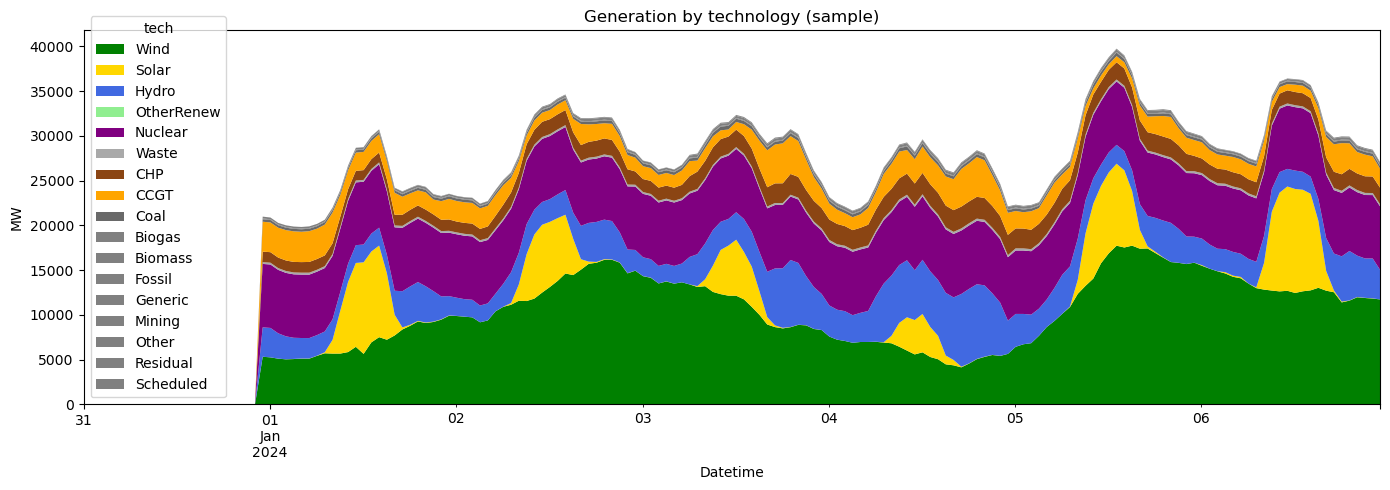

In [8]:
# --- Plot `gen_by_tech` (stacked area) ---
import matplotlib.pyplot as plt

if 'gen_by_tech' not in globals():
    raise RuntimeError('`gen_by_tech` not found. Run the earlier cell that constructs it first.')

# choose sample length (first week = 168 hours) for readability
sample_hours = 168
sample = gen_by_tech.iloc[:sample_hours] if len(gen_by_tech) >= sample_hours else gen_by_tech

# drop the demand column before plotting
plot_df = sample.drop(columns=['demand'], errors='ignore')

# define a consistent color mapping for technologies
color_map = {
    'Wind': 'green',
    'Solar': 'gold',
    'Hydro': 'royalblue',
    'Coal': 'dimgray',
    'Nuclear': 'purple',
    'Diesel': 'red',
    'CCGT': 'orange',
    'CHP': 'saddlebrown',
    'HVDC': 'black',
    'OtherRenew': 'lightgreen',
    'Waste': 'darkgray'
}

# Order technologies by cost (cheapest at bottom, most expensive at top)
# This order is based on typical marginal costs
tech_cost_order = ['Wind', 'Solar', 'Hydro', 'OtherRenew', 'Nuclear', 'Waste', 'HVDC', 'CHP', 'CCGT', 'Coal', 'Diesel']
ordered_cols = [col for col in tech_cost_order if col in plot_df.columns]
# Add any remaining columns not in the order list
ordered_cols += [col for col in plot_df.columns if col not in ordered_cols]
plot_df = plot_df[ordered_cols]

# pick colors in the order of plot columns; fallback to gray if not mapped
colors = [color_map.get(col, 'gray') for col in plot_df.columns]


ax = plot_df.plot.area(figsize=(14,5), linewidth=0, color=colors)

ax.set_title('Generation by technology (sample)')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

**Renewable energy limits and Demand for the optimization**

Wind capacity: 31020.20 MW
Solar capacity: 33947.12 MW
Hydro capacity: 17096.96 MW

Winter: found 12 full weeks
Winter week range: 2024-12-22 00:00:00+00:00 to 2024-12-28 23:00:00+00:00

Summer: found 13 full weeks
Summer week range: 2024-06-29 00:00:00+00:00 to 2024-07-05 23:00:00+00:00



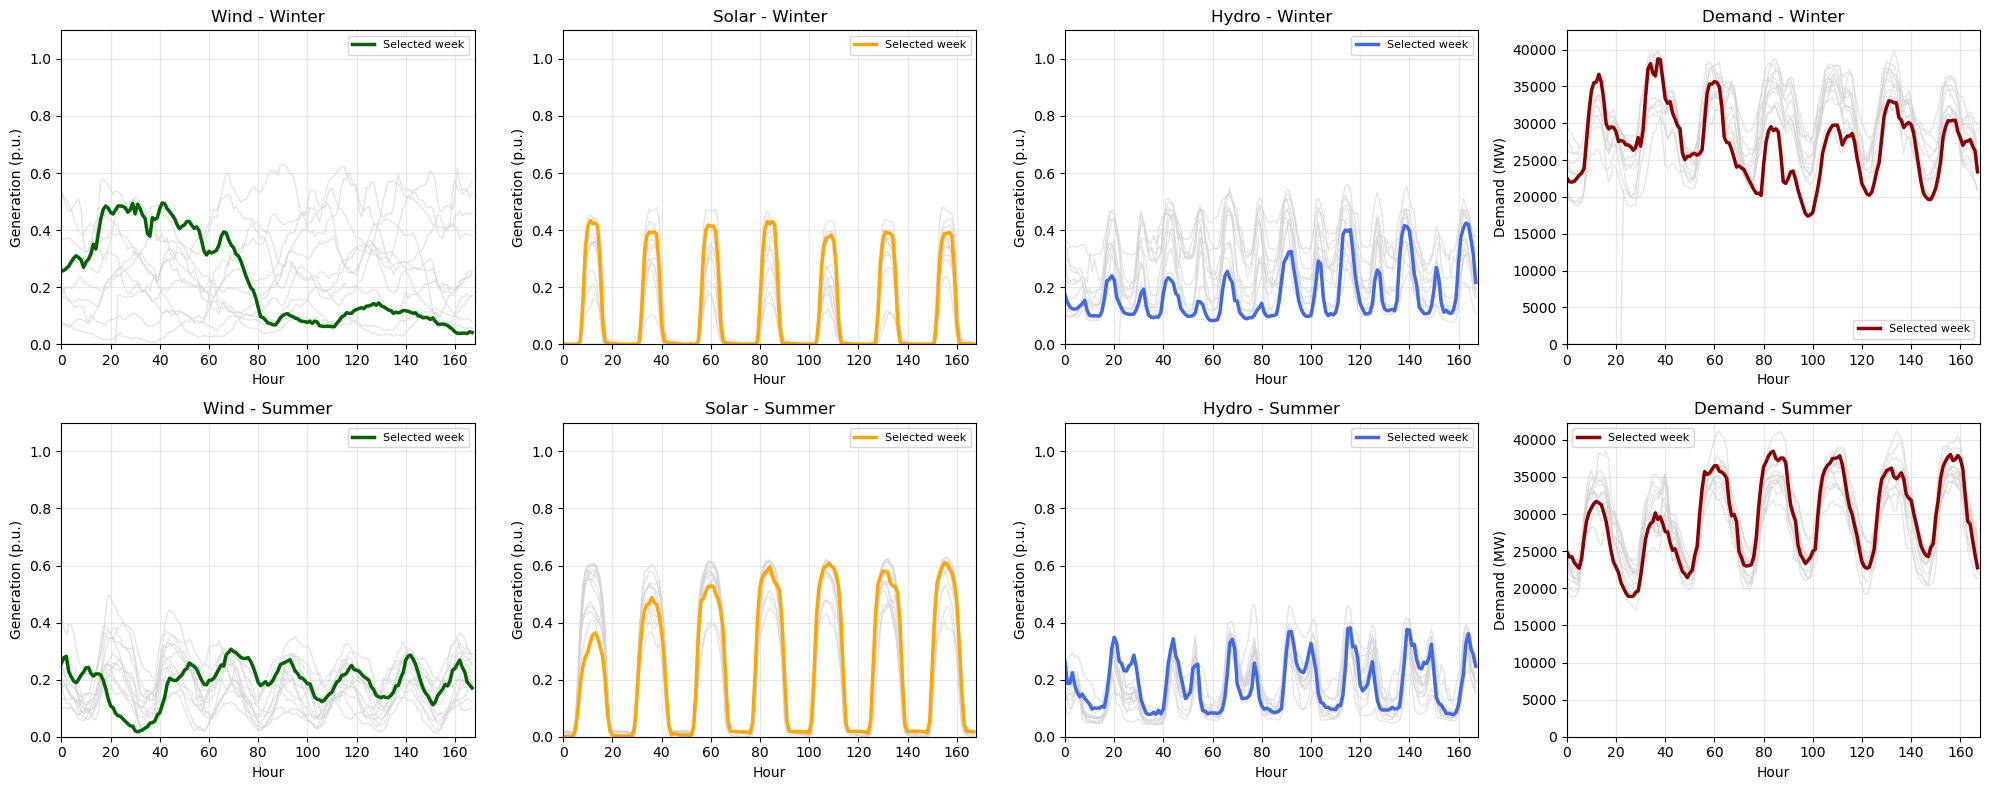

In [9]:
# --- Calculate p.u. generation for Wind, Solar, and Hydro + Demand ---
season_months = {
    'Winter': [12, 1, 2],
    'Summer': [6, 7, 8]
}

# Get capacities for p.u. calculation
wind_cap = tech_caps.get('Wind', 1.0)
solar_cap = tech_caps.get('Solar', 1.0)
hydro_cap = tech_caps.get('Hydro', 1.0)

print(f"Wind capacity: {wind_cap:.2f} MW")
print(f"Solar capacity: {solar_cap:.2f} MW")
print(f"Hydro capacity: {hydro_cap:.2f} MW\n")

# Store all weekly data and random selection per season
all_weekly_data = {}
pu_gen = {}

for season, months in season_months.items():
    # Subset data for season
    gb = gen_by_tech.copy()
    season_data = gb[gb.index.month.isin(months)]
    
    # Extract 7-day windows
    weekly = []
    start = season_data.index[0].floor('D')
    end = season_data.index[-1].ceil('D')
    current = start
    while current + pd.Timedelta(days=7) <= end:
        week_slice = season_data.loc[current:current + pd.Timedelta(days=7) - pd.Timedelta(hours=1)]
        if len(week_slice) == 168:
            weekly.append(week_slice)
        current += pd.Timedelta(days=7)
    
    print(f"{season}: found {len(weekly)} full weeks")
    
    # Store all weeks' p.u. data and demand
    all_weekly_data[season] = {'Wind': [], 'Solar': [], 'Hydro': [], 'Demand': []}
    for week_data in weekly:
        all_weekly_data[season]['Wind'].append(week_data.get('Wind', pd.Series(0, index=week_data.index)).values / wind_cap)
        all_weekly_data[season]['Solar'].append(week_data.get('Solar', pd.Series(0, index=week_data.index)).values / solar_cap)
        all_weekly_data[season]['Hydro'].append(week_data.get('Hydro', pd.Series(0, index=week_data.index)).values / hydro_cap)
        all_weekly_data[season]['Demand'].append(week_data.get('demand', pd.Series(0, index=week_data.index)).values)
    
    # Select random week
    if weekly:
        random_idx = np.random.randint(0, len(weekly))
        random_week = weekly[random_idx]
        
        # Store random week data
        pu_gen[season] = pd.DataFrame(index=random_week.index)
        pu_gen[season]['Wind'] = random_week.get('Wind', pd.Series(0, index=random_week.index)) / wind_cap
        pu_gen[season]['Solar'] = random_week.get('Solar', pd.Series(0, index=random_week.index)) / solar_cap
        pu_gen[season]['Hydro'] = random_week.get('Hydro', pd.Series(0, index=random_week.index)) / hydro_cap
        pu_gen[season]['Demand'] = random_week.get('demand', pd.Series(0, index=random_week.index))
        
        print(f"{season} week range: {random_week.index[0]} to {random_week.index[-1]}\n")

# Plot p.u. generation and demand for random weeks with all weeks in background
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

colors = {'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue', 'Demand': 'darkred'}

# Calculate common x-axis limits
x_max = max(len(data) for data in pu_gen.values())

for row, (season, data) in enumerate(pu_gen.items()):
    for col, tech in enumerate(['Wind', 'Solar', 'Hydro', 'Demand']):
        ax = axes[row, col]
        
        # Plot all weeks in light grey
        for week_profile in all_weekly_data[season][tech]:
            ax.plot(range(len(week_profile)), week_profile, 
                    color='lightgrey', linewidth=1.0, alpha=0.6)
        
        # Overlay random week in bold color
        ax.plot(range(len(data)), data[tech].values, 
                color=colors[tech], linewidth=2.5, label='Selected week')
        
        ax.set_title(f"{tech} - {season}")
        if tech == 'Demand':
            ax.set_ylabel('Demand (MW)')
            ax.set_ylim([0, max(data[tech].values) * 1.1])
        else:
            ax.set_ylabel('Generation (p.u.)')
            ax.set_ylim([0, 1.1])
        ax.set_xlabel('Hour')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, x_max])
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

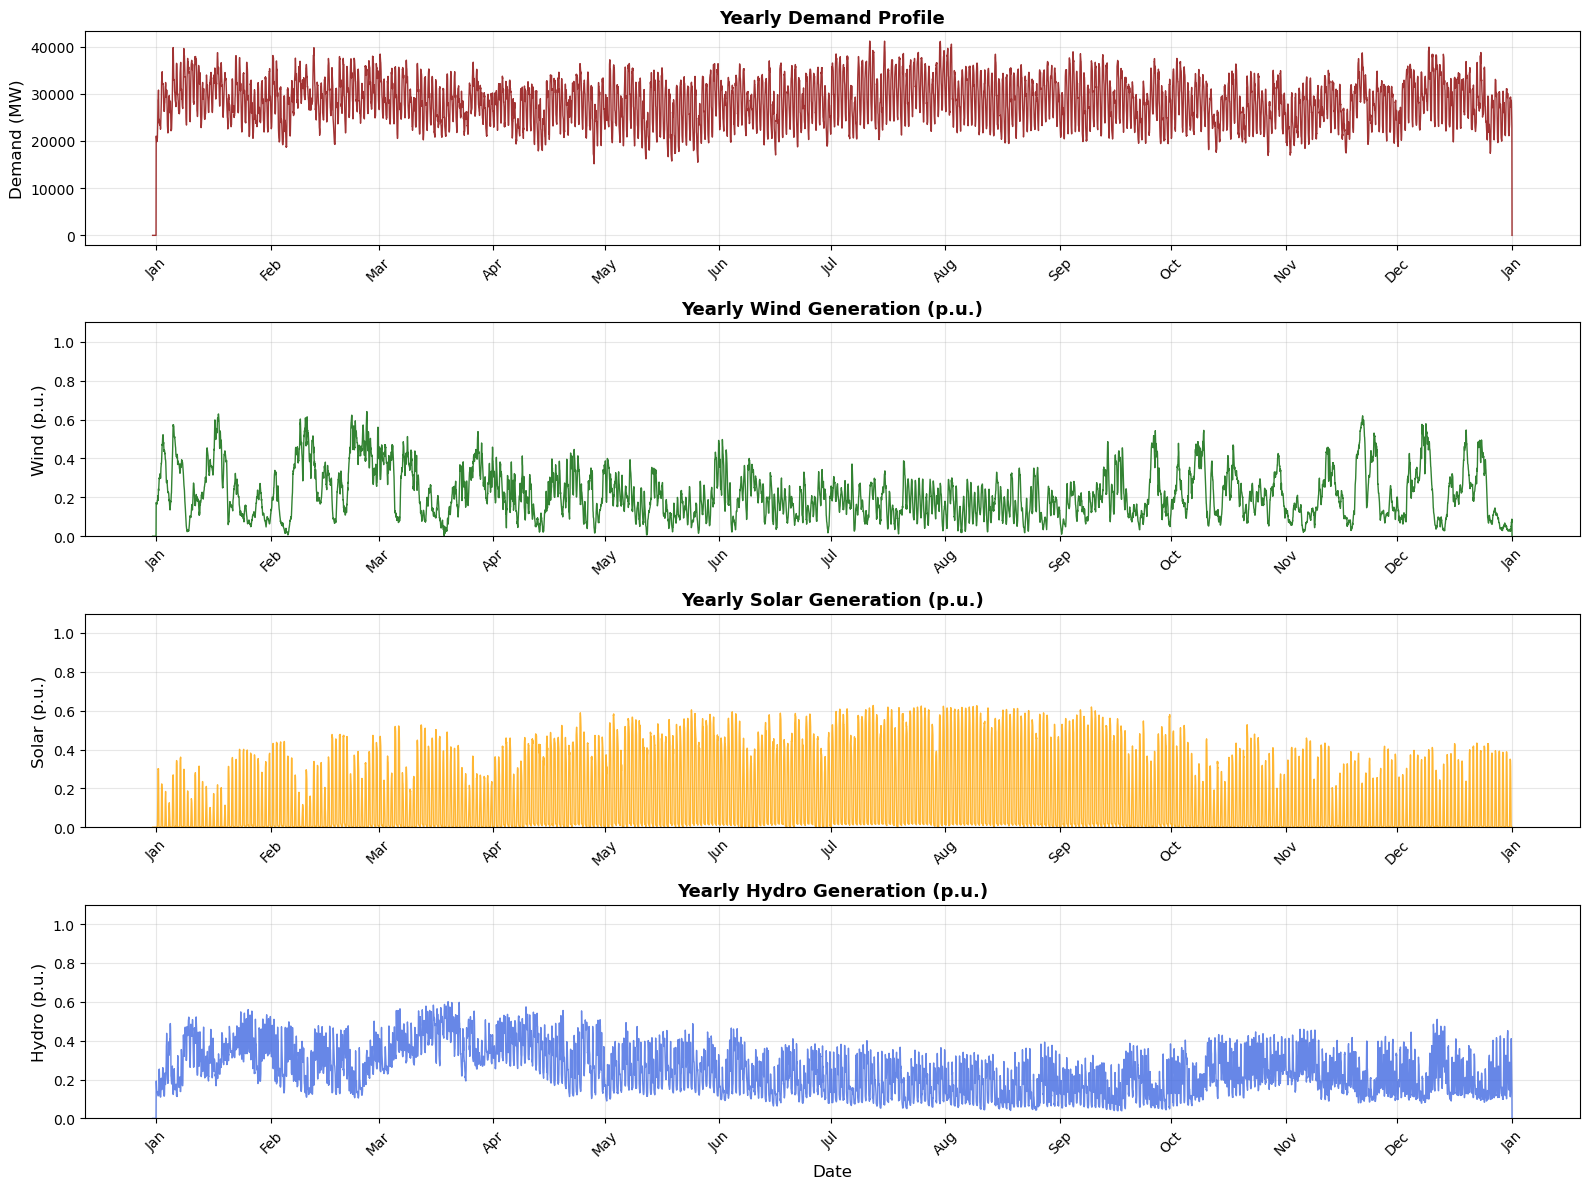

Demand (MW):
  Average: 28246.14
  Peak: 41177.93
  Min: 0.00

Wind Generation (p.u.):
  Average: 0.216
  Peak: 0.641
  Min: 0.000

Solar Generation (p.u.):
  Average: 0.161
  Peak: 0.627
  Min: 0.000

Hydro Generation (p.u.):
  Average: 0.240
  Peak: 0.601
  Min: 0.000


In [10]:
# Plot yearly Demand + Solar, Wind, and Hydro in p.u.
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Calculate p.u. values for each technology
wind_pu = gen_by_tech['Wind'] / wind_cap
solar_pu = gen_by_tech['Solar'] / solar_cap
hydro_pu = gen_by_tech['Hydro'] / hydro_cap
yearly_demand = gen_by_tech['demand']

# Plot Demand
axes[0].plot(yearly_demand.index, yearly_demand.values, color='darkred', linewidth=1, alpha=0.8)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_title('Yearly Demand Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Wind
axes[1].plot(wind_pu.index, wind_pu.values, color='darkgreen', linewidth=1, alpha=0.8)
axes[1].set_ylabel('Wind (p.u.)', fontsize=12)
axes[1].set_title('Yearly Wind Generation (p.u.)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.1])

# Plot Solar
axes[2].plot(solar_pu.index, solar_pu.values, color='orange', linewidth=1, alpha=0.8)
axes[2].set_ylabel('Solar (p.u.)', fontsize=12)
axes[2].set_title('Yearly Solar Generation (p.u.)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.1])

# Plot Hydro
axes[3].plot(hydro_pu.index, hydro_pu.values, color='royalblue', linewidth=1, alpha=0.8)
axes[3].set_ylabel('Hydro (p.u.)', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_title('Yearly Hydro Generation (p.u.)', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim([0, 1.1])

# Format x-axis to show months for all subplots
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("Demand (MW):")
print(f"  Average: {yearly_demand.mean():.2f}")
print(f"  Peak: {yearly_demand.max():.2f}")
print(f"  Min: {yearly_demand.min():.2f}\n")

print("Wind Generation (p.u.):")
print(f"  Average: {wind_pu.mean():.3f}")
print(f"  Peak: {wind_pu.max():.3f}")
print(f"  Min: {wind_pu.min():.3f}\n")

print("Solar Generation (p.u.):")
print(f"  Average: {solar_pu.mean():.3f}")
print(f"  Peak: {solar_pu.max():.3f}")
print(f"  Min: {solar_pu.min():.3f}\n")

print("Hydro Generation (p.u.):")
print(f"  Average: {hydro_pu.mean():.3f}")
print(f"  Peak: {hydro_pu.max():.3f}")
print(f"  Min: {hydro_pu.min():.3f}")

In [11]:
# =====================
# 5) Geographic Flow Map (Folium with Capacities)
# =====================
print("\n" + "="*70)
print("GEOGRAPHIC POWER FLOW MAP")
print("="*70)

try:
    import folium
    from folium import plugins
    from IPython.display import HTML
    
    # Bus coordinates (latitude, longitude)
    bus_coords = {
        "ES": (40.4637, -3.7492),      # Madrid area
        "FR": (48.8566, 2.3522),      # Paris area
        "IT": (41.9028, 12.4964),      # Rome area
        "PT": (38.7223, -9.1393)    # Lisbon area
    }
    
    # Network connections: (source, target, NTC_MW)
    power_flows = [
        ("ES", "FR", 3500),
        ("FR", "IT", 4500),
        ("ES", "IT", 2000),
        ("ES", "PT", 4500)
    ]
    
    # Create base map centered on Europe
    center_lat = sum(coord[0] for coord in bus_coords.values()) / len(bus_coords)
    center_lon = sum(coord[1] for coord in bus_coords.values()) / len(bus_coords)
    
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=5,
        tiles='OpenStreetMap',
        prefer_canvas=True
    )
    
    # Plot network connections with simple dash separators
    for source, target, flow_mw in power_flows:
        lat0, lon0 = bus_coords[source]
        lat1, lon1 = bus_coords[target]
        
        # Draw connection line (simple black line)
        folium.PolyLine(
            locations=[[lat0, lon0], [lat1, lon1]],
            color='black',
            weight=2,
            opacity=0.8,
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW",
            tooltip=f"{source} - {target}"
        ).add_to(m)
        
        # Add dash separator at midpoint
        mid_lat = (lat0 + lat1) / 2
        mid_lon = (lon0 + lon1) / 2
        
        label_html = f'''
        <div style="font-size: 16px; font-weight: bold; color: black; 
                    text-shadow: -1px -1px 1px white, 1px -1px 1px white, -1px 1px 1px white, 1px 1px 1px white;
                    background-color: rgba(255,255,255,0.75); padding: 4px 6px; border-radius: 3px; white-space: nowrap;">
        {source} - {target} {flow_mw} MW
        </div>
        '''
        
        folium.Marker(
            location=[mid_lat, mid_lon],
            icon=folium.DivIcon(html=label_html),
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW"
        ).add_to(m)
    
    # Plot substations (nodes) with larger markers
    for bus_name in bus_coords.keys():
        lat, lon = bus_coords[bus_name]
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=25,
            popup=f"<b>{bus_name}</b><br>400 kV Substation",
            tooltip=bus_name,
            color='#c92a2a',
            fill=True,
            fillColor='#ff6b6b',
            fillOpacity=0.95,
            weight=4,
            zindex=100
        ).add_to(m)
        
        # Add country label
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(html=f'''
            <div style="font-size: 12px; font-weight: bold; color: white;">
            {bus_name}
            </div>
            '''),
            popup=f"{bus_name} - 400 kV AC"
        ).add_to(m)
    
    # Add title with legend
    title_html = '''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 360px; height: auto;
                background-color: white; border:2px solid #333; z-index:9999; 
                font-size: 12px; padding: 10px; border-radius: 5px;
                box-shadow: 0 0 10px rgba(0,0,0,0.2);">
    <b style="font-size: 13px;">Network Capacity: 400 kV AC</b><br>
    <span style="font-size: 10px; color: #666;">Lines show NTC capacity</span><br>
    <div style="font-size: 10px; margin-top: 6px; line-height: 1.4;">
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Display the map
    print("Ã¢Å“â€œ Geographic capacity map created successfully!")
    display(HTML(m._repr_html_()))
    
except ImportError:
    print("Folium not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'folium', '-q'])
    print("Folium installed. Please rerun this cell.")
    
except Exception as e:
    print(f"Error: {type(e).__name__}: {str(e)}")
    print("Could not create geographic capacity map.")


GEOGRAPHIC POWER FLOW MAP
Ã¢Å“â€œ Geographic capacity map created successfully!


In [12]:
# --- Load generation data for each country ---
import pandas as pd
import numpy as np
from pathlib import Path

countries_data_path = Path('./Data/Countries interconnected Data')

# Dictionary to store generation by tech for each country
gen_by_tech_countries = {}

# Country mapping
country_files = {
    'France': 'France_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Italy': 'Italy_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Portugal': 'Portugal_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
}

for country, filename in country_files.items():
    filepath = countries_data_path / filename
    
    # Read the CSV
    df = pd.read_csv(filepath, sep=';')
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Parse timestamp column to extract datetime
    # Format: "01/01/2024 00:00:00 - 01/01/2024 01:00:00" (may have timezone like " (CET)")
    # Extract start time and remove any trailing timezone info
    timestep_start = df['Timestep'].str.split(' - ', n=1, expand=True, regex=False)[0]
    timestep_clean = timestep_start.str.split(' (', n=1, expand=True, regex=False)[0]
    df['datetime'] = pd.to_datetime(timestep_clean, format='%d/%m/%Y %H:%M:%S')
    
    # Function to clean values (convert 'n/e' and other non-numeric to 0)
    def clean_value(val):
        if pd.isna(val):
            return 0.0
        s = str(val).strip().lower()
        if s in ['n/e', 'n/a', '']:
            return 0.0
        try:
            return float(val)
        except:
            return 0.0
    
    # Extract and aggregate wind (Onshore + Offshore)
    wind_onshore = df.loc[:, 'Wind Onshore (MW)'].apply(clean_value).values
    wind_offshore = df.loc[:, 'Wind Offshore (MW)'].apply(clean_value).values
    wind = wind_onshore + wind_offshore
    
    # Extract solar
    solar = df.loc[:, 'Solar (MW)'].apply(clean_value).values
    
    # Extract hydro (Reservoir + Run-of-river & pondage)
    # Note: Excluding pumped storage as it's not main generation
    hydro_reservoir = df.loc[:, 'Hydro Water Reservoir (MW)'].apply(clean_value).values
    hydro_runofriver = df.loc[:, 'Hydro Run-of-river and pondage (MW)'].apply(clean_value).values
    hydro = hydro_reservoir + hydro_runofriver
    
    # Extract nuclear and fossil fuel generation
    nuclear = df.loc[:, 'Nuclear (MW)'].apply(clean_value).values
    coal = df.loc[:, 'Fossil Hard coal (MW)'].apply(clean_value).values
    fossil_gas = df.loc[:, 'Fossil Gas (MW)'].apply(clean_value).values
    
    # Create generation by tech dataframe (before setting index to handle duplicates)
    gen_df = pd.DataFrame({
        'datetime': df['datetime'],
        'Wind': wind,
        'Solar': solar,
        'Hydro': hydro,
        'Nuclear': nuclear,
        'Coal': coal,
        'Fossil Gas': fossil_gas,
    })
    
    # Handle duplicate timestamps by taking the mean (in case of DST transitions)
    gen_by_tech = gen_df.groupby('datetime').mean()
    gen_by_tech.index.name = 'datetime'
    
    # Ensure hourly frequency (reindex to fill any gaps)
    full_index = pd.date_range(
        start=gen_by_tech.index.min().floor('D'),
        end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1),
        freq='h'
    )
    gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
    gen_by_tech.index.name = 'datetime'
    
    # Add demand as sum of all generation
    gen_by_tech['demand'] = gen_by_tech[['Wind', 'Solar', 'Hydro', 'Nuclear', 'Coal', 'Fossil Gas']].sum(axis=1)
    
    gen_by_tech_countries[country] = gen_by_tech
    
    print(f"\n{country}:")
    print(f"  Shape: {gen_by_tech.shape}")
    print(f"  Date range: {gen_by_tech.index.min()} to {gen_by_tech.index.max()}")
    print(f"  Average demand: {gen_by_tech['demand'].mean():.1f} MW")
    display(gen_by_tech.head())


France:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 58104.5 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,14977.0,225.0,6303.0,40387.0,15.0,1810.0,63717.0
2024-01-01 01:00:00,14734.0,0.0,6049.0,37528.0,16.0,1840.0,60167.0
2024-01-01 02:00:00,14367.0,0.0,5923.0,37320.0,16.0,1787.0,59413.0
2024-01-01 03:00:00,13393.0,0.0,5812.0,36954.0,15.0,1778.0,57952.0
2024-01-01 04:00:00,8607.0,0.0,5661.0,36906.0,15.0,1765.0,52954.0



Italy:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 21994.3 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,3905.0,0.0,2358.0,0.0,423.0,8652.0,15338.0
2024-01-01 01:00:00,3927.0,0.0,2195.0,0.0,424.0,7679.0,14225.0
2024-01-01 02:00:00,4041.0,0.0,2051.0,0.0,424.0,6774.0,13290.0
2024-01-01 03:00:00,4122.0,0.0,2008.0,0.0,424.0,6516.0,13070.0
2024-01-01 04:00:00,4018.0,0.0,1912.0,0.0,424.0,6308.0,12662.0



Portugal:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 4095.9 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,351.9,0.1,902.2,0.0,0.0,190.9,1445.1
2024-01-01 01:00:00,342.7,0.0,776.0,0.0,0.0,192.7,1311.4
2024-01-01 02:00:00,413.9,0.0,643.4,0.0,0.0,190.1,1247.4
2024-01-01 03:00:00,487.1,0.0,1239.3,0.0,0.0,189.7,1916.1
2024-01-01 04:00:00,510.7,0.0,930.5,0.0,0.0,189.9,1631.1



MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR


Processing: Spain (p.u. data already available)

Data range: 2023-12-31 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Total hours: 8808 hours

Demand Statistics:
  Average: 28,246 MW
  Peak: 41,178 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.216 (21.6%)
  Solar: 0.161 (16.1%)
  Hydro: 0.240 (24.0%)


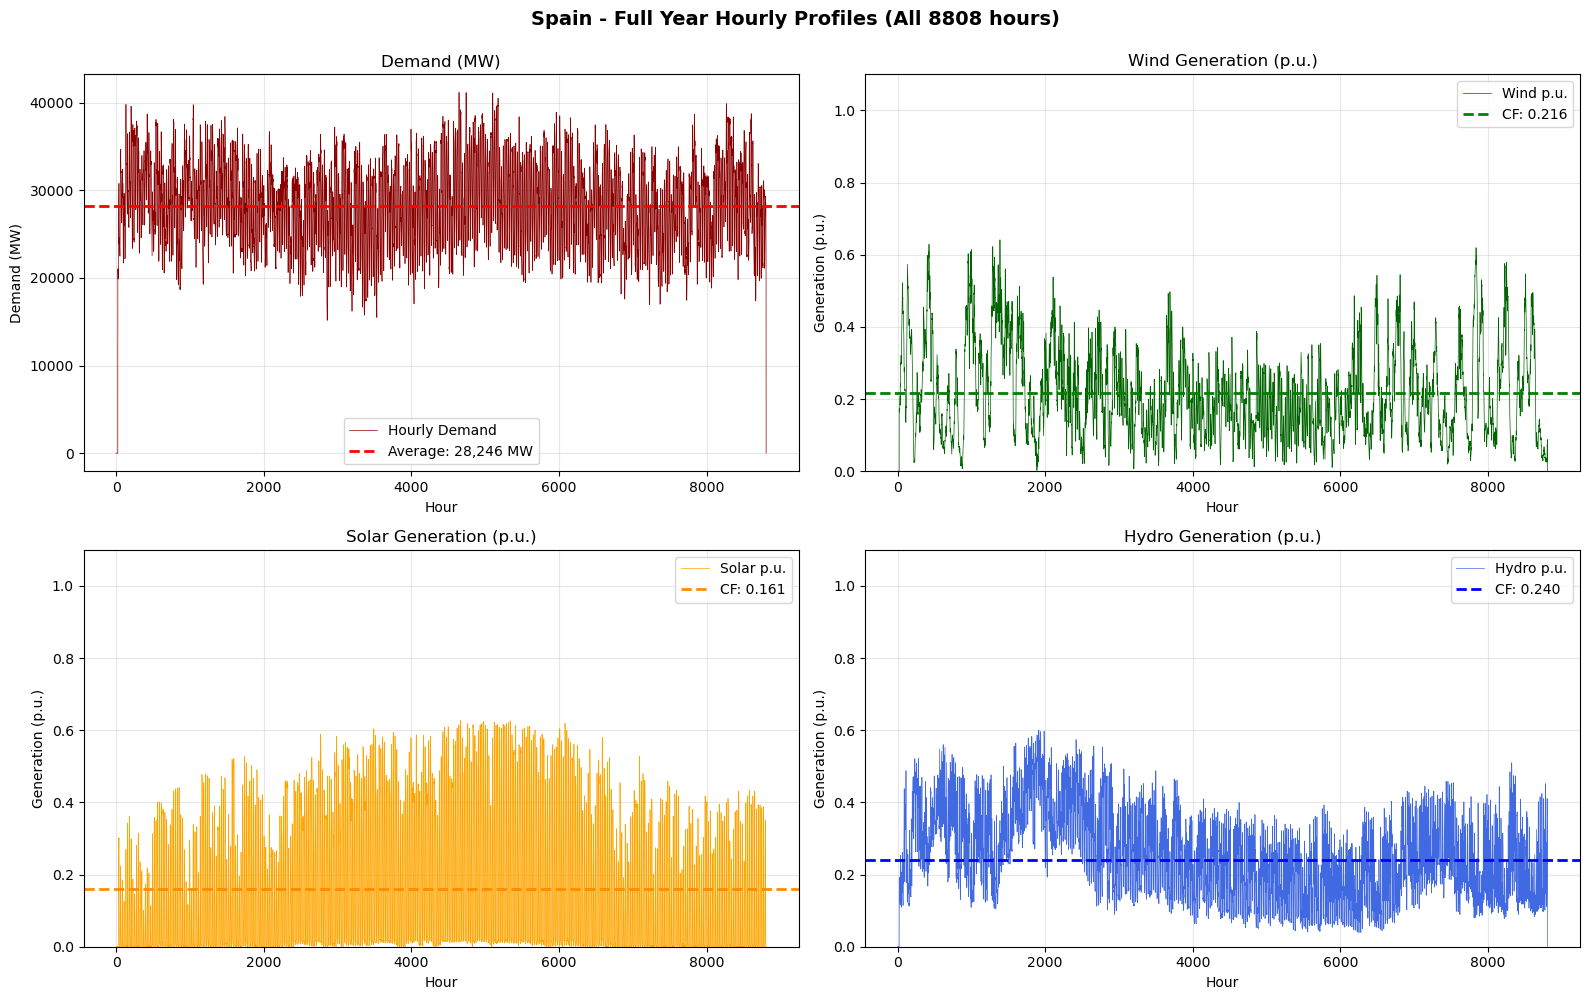


Ã¢Å“â€œ Spain full-year plots completed

Installed capacities for other countries (MW):
  France: Wind=24,500, Solar=20,000, Hydro=25,500
  Italy: Wind=13,600, Solar=37,500, Hydro=22,089
  Portugal: Wind=6,000, Solar=3,500, Hydro=7,200


Processing: France

Installed capacity (p.u. basis):
  Wind: 24,500 MW
  Solar: 20,000 MW
  Hydro: 25,500 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 58,105 MW
  Peak: 81,066 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.213 (21.3%)
  Solar: 0.133 (13.3%)
  Hydro: 0.283 (28.3%)


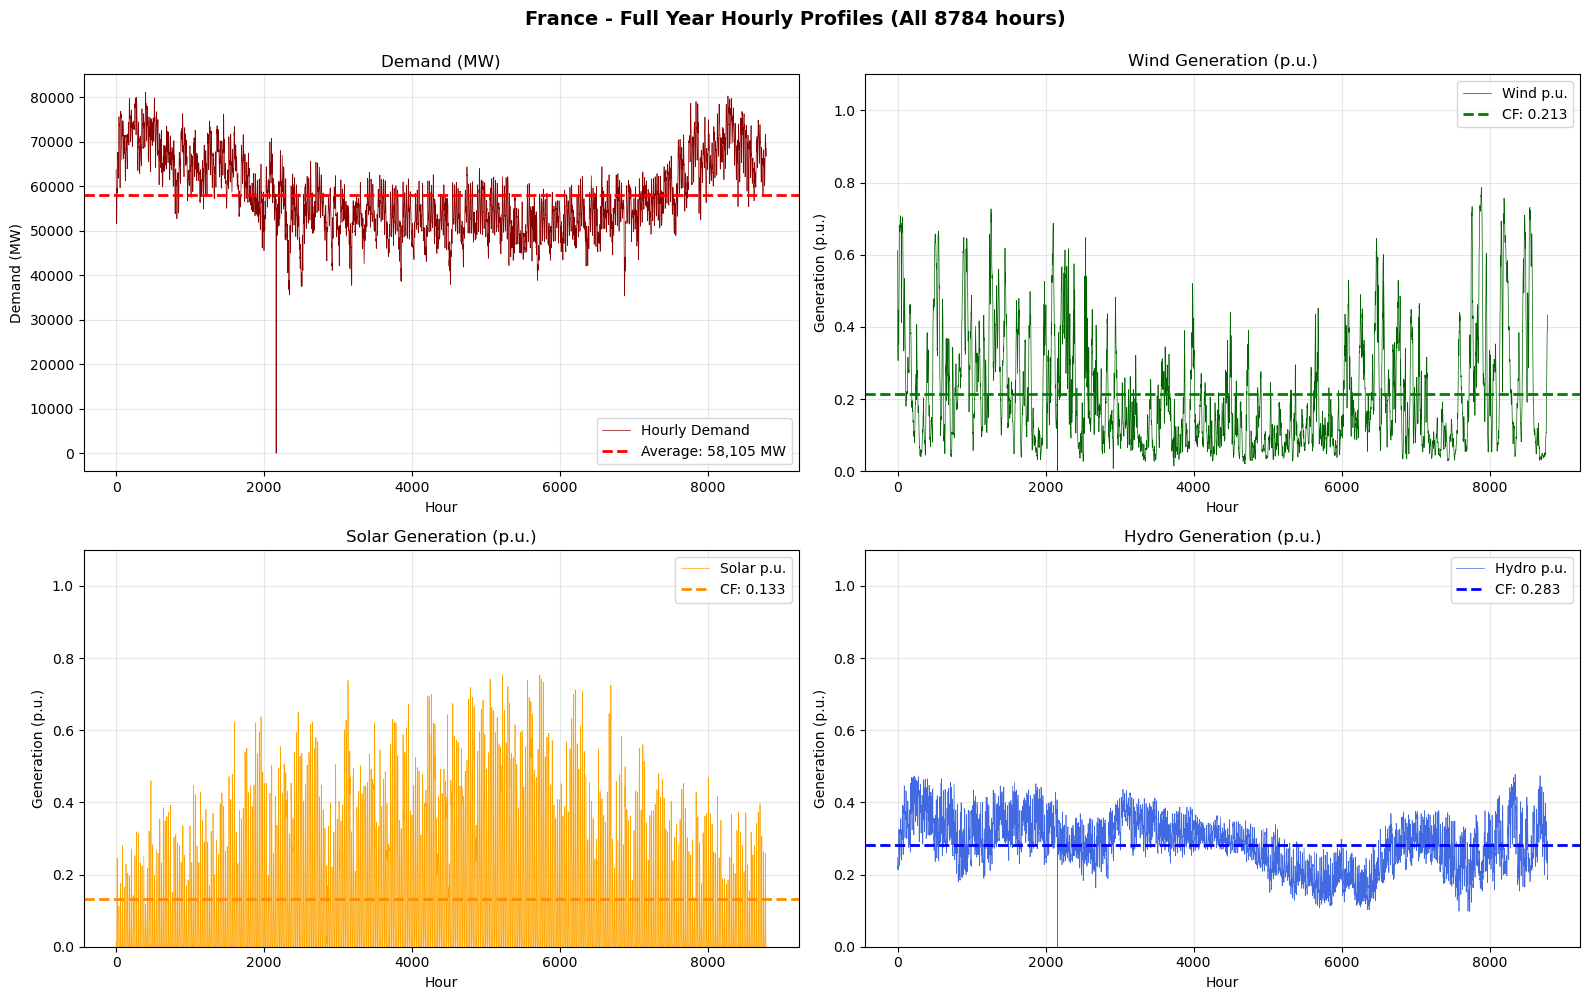


Ã¢Å“â€œ France full-year plots completed


Processing: Italy

Installed capacity (p.u. basis):
  Wind: 13,600 MW
  Solar: 37,500 MW
  Hydro: 22,089 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 21,994 MW
  Peak: 41,529 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.184 (18.4%)
  Solar: 0.084 (8.4%)
  Hydro: 0.238 (23.8%)


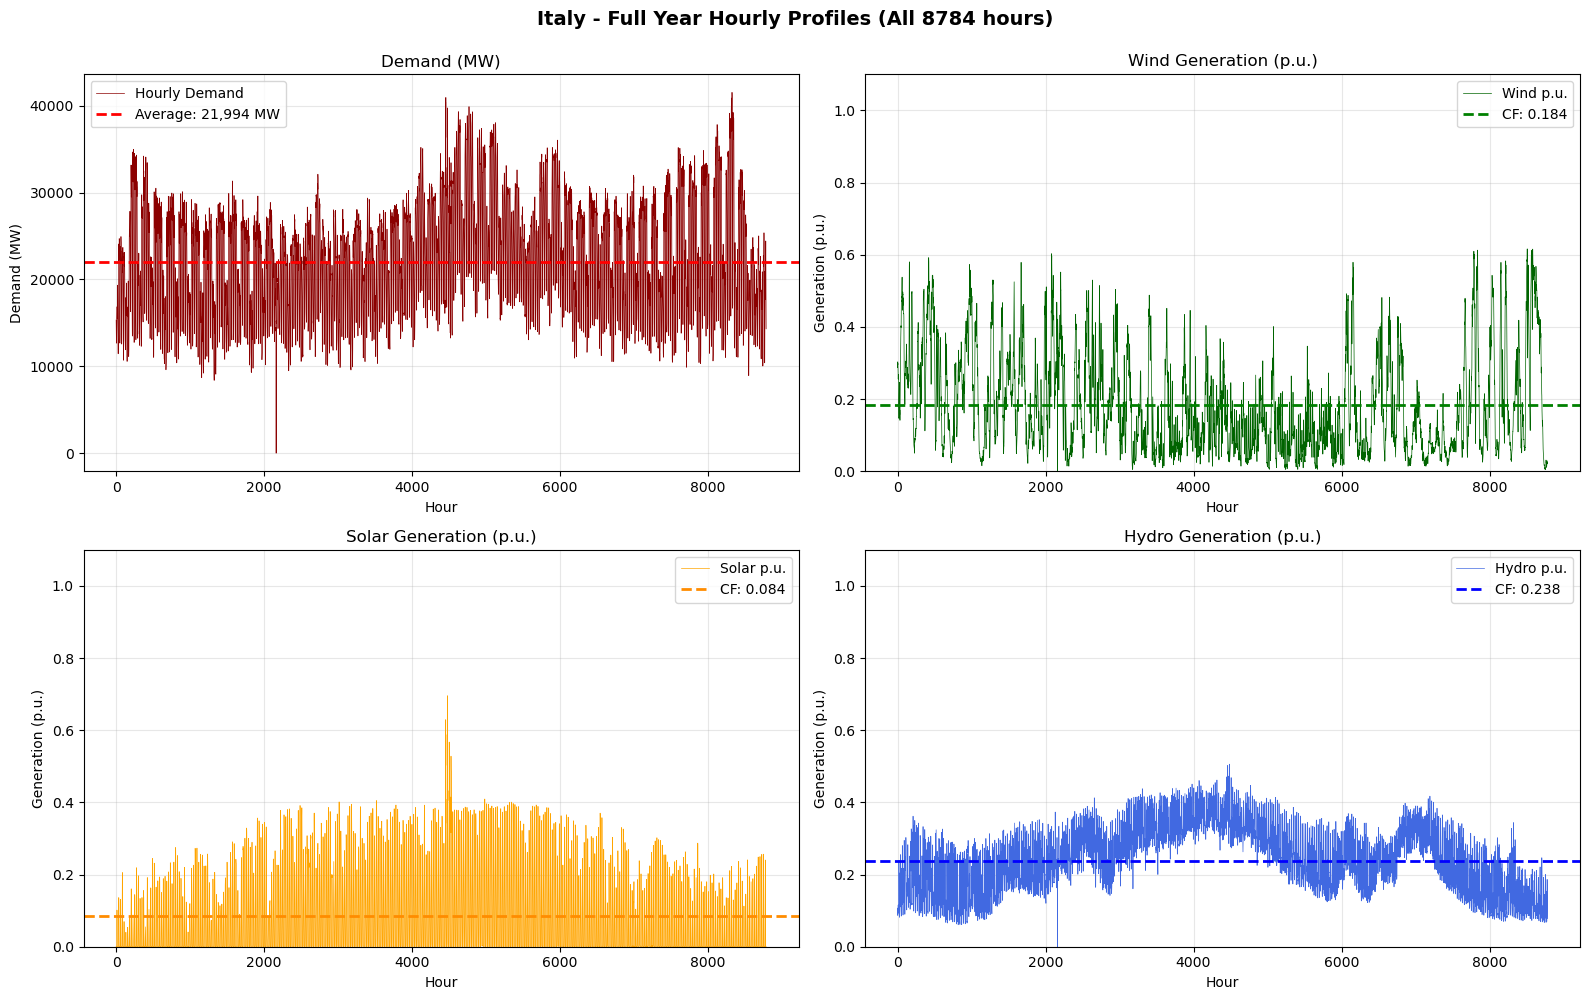


Ã¢Å“â€œ Italy full-year plots completed


Processing: Portugal

Installed capacity (p.u. basis):
  Wind: 6,000 MW
  Solar: 3,500 MW
  Hydro: 7,200 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 4,096 MW
  Peak: 9,674 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.268 (26.8%)
  Solar: 0.160 (16.0%)
  Hydro: 0.190 (19.0%)


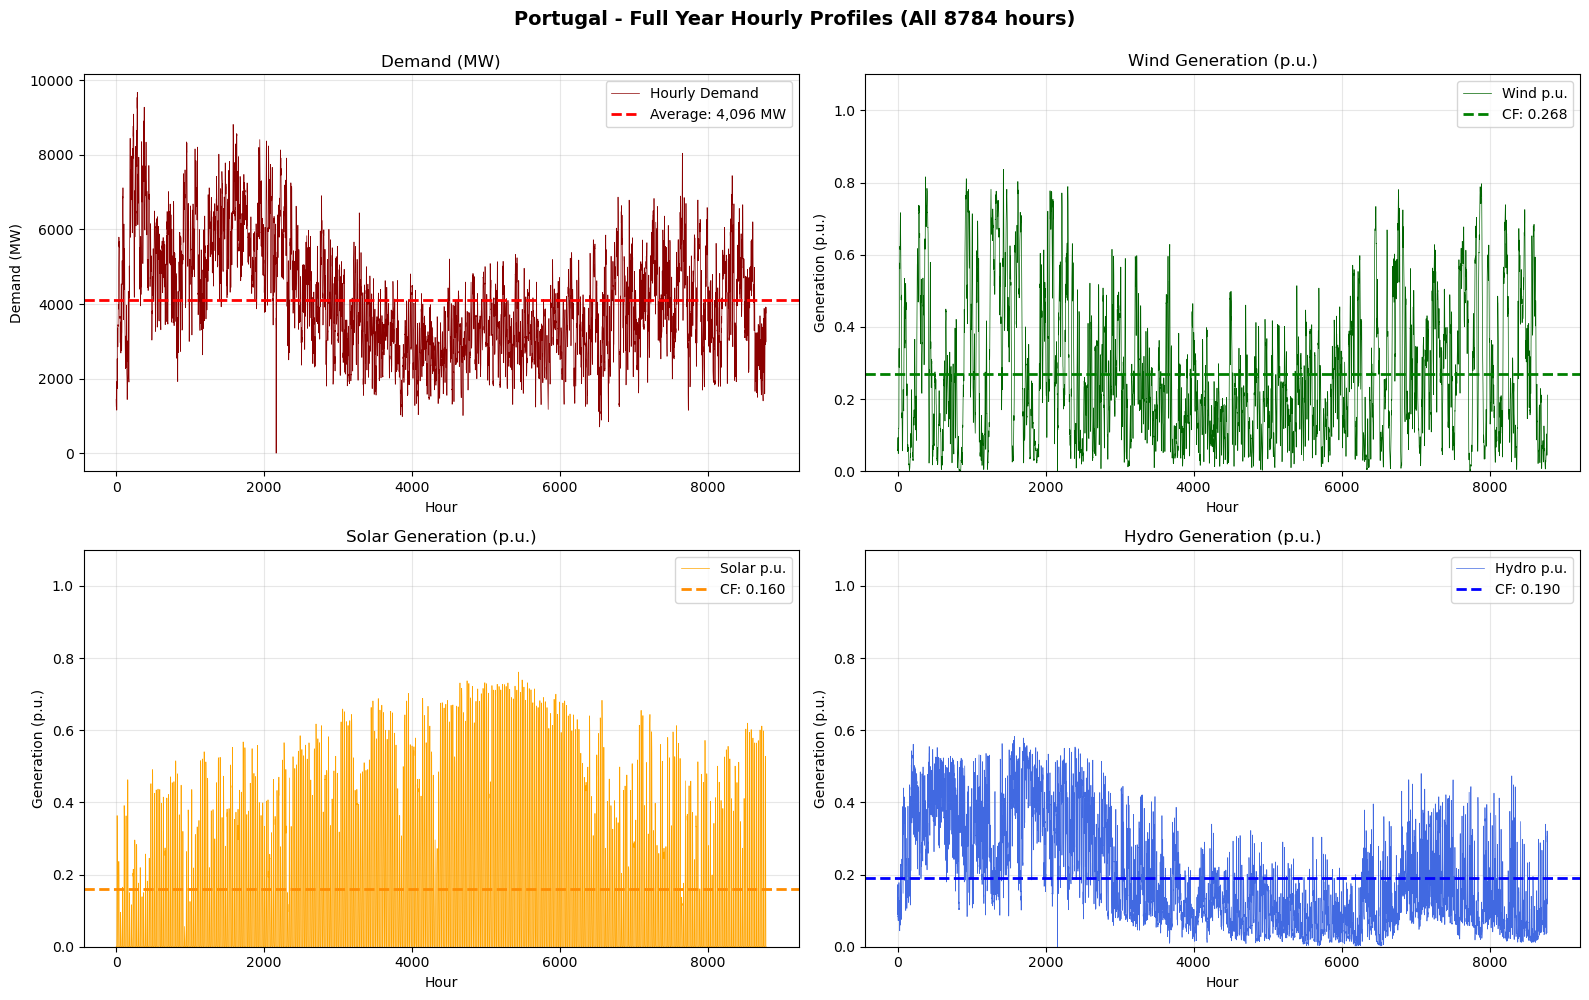


Ã¢Å“â€œ Portugal full-year plots completed

Multi-country analysis complete!

AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)

Ã¢Å“â€œ all_countries_hourly_demand - Dictionary containing hourly demand for each country:
  Spain: 8808 hourly values (MW)
  France: 8784 hourly values (MW)
  Italy: 8784 hourly values (MW)
  Portugal: 8784 hourly values (MW)

Ã¢Å“â€œ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:
  Spain:
    Wind: 8808 hourly values (p.u.)
    Solar: 8808 hourly values (p.u.)
    Hydro: 8808 hourly values (p.u.)
  France:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Italy:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Portugal:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)

Total hours per country: 8808
Equivalent to: 367.0 days (100.5% of

In [13]:
# --- Plot p.u. generation for all countries (FULL YEAR) ---
import matplotlib.pyplot as plt
print("\n" + "="*70)
print("MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR")
print("="*70 + "\n")

# Initialize aggregated variables
all_countries_hourly_demand = {}
all_countries_pu_renewables = {}

# ===== SPAIN (already in p.u.) =====
print(f"\n{'='*70}")
print("Processing: Spain (p.u. data already available)")
print(f"{'='*70}")
print(f"\nData range: {wind_pu.index[0]} to {wind_pu.index[-1]}")
print(f"Total hours: {len(wind_pu)} hours\n")

# Store Spain's already-calculated p.u. series
spain_wind_pu = wind_pu.values if hasattr(wind_pu, 'values') else wind_pu
spain_solar_pu = solar_pu.values if hasattr(solar_pu, 'values') else solar_pu
spain_hydro_pu = hydro_pu.values if hasattr(hydro_pu, 'values') else hydro_pu
spain_demand = yearly_demand.values if hasattr(yearly_demand, 'values') else yearly_demand

# Calculate capacity factors for Spain
spain_wind_cf = np.mean(spain_wind_pu)
spain_solar_cf = np.mean(spain_solar_pu)
spain_hydro_cf = np.mean(spain_hydro_pu)
spain_avg_demand = np.mean(spain_demand)
spain_peak_demand = np.max(spain_demand)
spain_min_demand = np.min(spain_demand)

print(f"Demand Statistics:")
print(f"  Average: {spain_avg_demand:,.0f} MW")
print(f"  Peak: {spain_peak_demand:,.0f} MW")
print(f"  Minimum: {spain_min_demand:,.0f} MW")
print(f"\nRenewable Capacity Factors (mean p.u.):")
print(f"  Wind: {spain_wind_cf:.3f} ({spain_wind_cf*100:.1f}%)")
print(f"  Solar: {spain_solar_cf:.3f} ({spain_solar_cf*100:.1f}%)")
print(f"  Hydro: {spain_hydro_cf:.3f} ({spain_hydro_cf*100:.1f}%)")

# Store Spain data
all_countries_hourly_demand['Spain'] = spain_demand
all_countries_pu_renewables['Spain'] = {
    'Wind': spain_wind_pu,
    'Solar': spain_solar_pu,
    'Hydro': spain_hydro_pu
}

# Plot Spain
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Spain - Full Year Hourly Profiles (All {len(spain_wind_pu)} hours)', 
             fontsize=14, fontweight='bold', y=0.995)

ax = axes[0, 0]
ax.plot(range(len(spain_demand)), spain_demand, color='darkred', linewidth=0.5, label='Hourly Demand')
ax.axhline(spain_avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {spain_avg_demand:,.0f} MW')
ax.set_title('Demand (MW)')
ax.set_ylabel('Demand (MW)')
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(range(len(spain_wind_pu)), spain_wind_pu, color='darkgreen', linewidth=0.5, label='Wind p.u.')
ax.axhline(spain_wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {spain_wind_cf:.3f}')
ax.set_title('Wind Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
ax.plot(range(len(spain_solar_pu)), spain_solar_pu, color='orange', linewidth=0.5, label='Solar p.u.')
ax.axhline(spain_solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {spain_solar_cf:.3f}')
ax.set_title('Solar Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(range(len(spain_hydro_pu)), spain_hydro_pu, color='royalblue', linewidth=0.5, label='Hydro p.u.')
ax.axhline(spain_hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {spain_hydro_cf:.3f}')
ax.set_title('Hydro Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print(f"\nÃ¢Å“â€œ Spain full-year plots completed\n")

# ===== OTHER COUNTRIES (calculate p.u. from installed capacity) =====
# Define installed capacities for other countries (GW converted to MW)
wind_cap_country = {
    "France": 24500,
    "Italy": 13600,
    "Portugal": 6000
}

solar_cap_country = {
    "France": 20000,
    "Italy": 37500,
    "Portugal": 3500
}

hydro_cap_country = {
    "France": 25500,
    "Italy": 22089,
    "Portugal": 7200
}

print("Installed capacities for other countries (MW):")
for country in wind_cap_country.keys():
    print(f"  {country}: Wind={wind_cap_country[country]:,}, Solar={solar_cap_country[country]:,}, Hydro={hydro_cap_country[country]:,}")
print()

# Loop through other countries
for country_name, gen_by_tech_country in gen_by_tech_countries.items():
    print(f"\n{'='*70}")
    print(f"Processing: {country_name}")
    print(f"{'='*70}")
    
    wind_cap = wind_cap_country.get(country_name, 1000.0)
    solar_cap = solar_cap_country.get(country_name, 1000.0)
    hydro_cap = hydro_cap_country.get(country_name, 1000.0)
    
    print(f"\nInstalled capacity (p.u. basis):")
    print(f"  Wind: {wind_cap:,.0f} MW")
    print(f"  Solar: {solar_cap:,.0f} MW")
    print(f"  Hydro: {hydro_cap:,.0f} MW")
    print(f"\nData range: {gen_by_tech_country.index[0]} to {gen_by_tech_country.index[-1]}")
    print(f"Total hours: {len(gen_by_tech_country)} hours\n")
    
    # Calculate p.u. for this country
    demand_arr = gen_by_tech_country['demand'].values
    wind_pu_arr = gen_by_tech_country['Wind'].values / wind_cap if wind_cap > 0 else np.zeros(len(gen_by_tech_country))
    solar_pu_arr = gen_by_tech_country['Solar'].values / solar_cap if solar_cap > 0 else np.zeros(len(gen_by_tech_country))
    hydro_pu_arr = gen_by_tech_country['Hydro'].values / hydro_cap if hydro_cap > 0 else np.zeros(len(gen_by_tech_country))
    
    # Calculate statistics
    avg_demand = np.mean(demand_arr)
    peak_demand = np.max(demand_arr)
    min_demand = np.min(demand_arr)
    wind_cf = np.mean(wind_pu_arr)
    solar_cf = np.mean(solar_pu_arr)
    hydro_cf = np.mean(hydro_pu_arr)
    
    print(f"Demand Statistics:")
    print(f"  Average: {avg_demand:,.0f} MW")
    print(f"  Peak: {peak_demand:,.0f} MW")
    print(f"  Minimum: {min_demand:,.0f} MW")
    print(f"\nRenewable Capacity Factors (mean p.u.):")
    print(f"  Wind: {wind_cf:.3f} ({wind_cf*100:.1f}%)")
    print(f"  Solar: {solar_cf:.3f} ({solar_cf*100:.1f}%)")
    print(f"  Hydro: {hydro_cf:.3f} ({hydro_cf*100:.1f}%)")
    
    # Store data
    all_countries_hourly_demand[country_name] = demand_arr
    all_countries_pu_renewables[country_name] = {
        'Wind': wind_pu_arr,
        'Solar': solar_pu_arr,
        'Hydro': hydro_pu_arr
    }
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{country_name} - Full Year Hourly Profiles (All {len(gen_by_tech_country)} hours)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    ax = axes[0, 0]
    ax.plot(range(len(demand_arr)), demand_arr, color='darkred', linewidth=0.5, label='Hourly Demand')
    ax.axhline(avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_demand:,.0f} MW')
    ax.set_title('Demand (MW)')
    ax.set_ylabel('Demand (MW)')
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[0, 1]
    ax.plot(range(len(wind_pu_arr)), wind_pu_arr, color='darkgreen', linewidth=0.5, label='Wind p.u.')
    ax.axhline(wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {wind_cf:.3f}')
    ax.set_title('Wind Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 0]
    ax.plot(range(len(solar_pu_arr)), solar_pu_arr, color='orange', linewidth=0.5, label='Solar p.u.')
    ax.axhline(solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {solar_cf:.3f}')
    ax.set_title('Solar Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 1]
    ax.plot(range(len(hydro_pu_arr)), hydro_pu_arr, color='royalblue', linewidth=0.5, label='Hydro p.u.')
    ax.axhline(hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {hydro_cf:.3f}')
    ax.set_title('Hydro Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"\nÃ¢Å“â€œ {country_name} full-year plots completed\n")

print("="*70)
print("Multi-country analysis complete!")
print("="*70)

# Create aggregated variables summary
print("\n" + "="*70)
print("AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)")
print("="*70 + "\n")

print("Ã¢Å“â€œ all_countries_hourly_demand - Dictionary containing hourly demand for each country:")
for country in all_countries_hourly_demand:
    print(f"  {country}: {len(all_countries_hourly_demand[country])} hourly values (MW)")

print("\nÃ¢Å“â€œ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:")
for country in all_countries_pu_renewables:
    print(f"  {country}:")
    for tech in ['Wind', 'Solar', 'Hydro']:
        n_hours = len(all_countries_pu_renewables[country][tech])
        print(f"    {tech}: {n_hours} hourly values (p.u.)")

total_hours_per_country = len(list(all_countries_hourly_demand.values())[0]) if all_countries_hourly_demand else 0
print(f"\nTotal hours per country: {total_hours_per_country}")
print(f"Equivalent to: {total_hours_per_country/24:.1f} days ({total_hours_per_country/8760*100:.1f}% of full year)")

print("\n" + "="*70)
print("Variables are ready for further analysis!")
print("="*70)

In [14]:
# =====================
# 1. Prepare multi-country data from existing structures
# =====================

print("="*70)
print("1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA")
print("="*70)

# Convert available data structures to optimization format
demands_multi = {
    'ES': all_countries_hourly_demand['Spain'] if 'Spain' in all_countries_hourly_demand else np.array([]),
    'FR': all_countries_hourly_demand['France'] if 'France' in all_countries_hourly_demand else np.array([]),
    'IT': all_countries_hourly_demand['Italy'] if 'Italy' in all_countries_hourly_demand else np.array([]),
    'PT': all_countries_hourly_demand['Portugal'] if 'Portugal' in all_countries_hourly_demand else np.array([]),
}

renewable_profiles_multi = {
    'ES': all_countries_pu_renewables['Spain'] if 'Spain' in all_countries_pu_renewables else {},
    'FR': all_countries_pu_renewables['France'] if 'France' in all_countries_pu_renewables else {},
    'IT': all_countries_pu_renewables['Italy'] if 'Italy' in all_countries_pu_renewables else {},
    'PT': all_countries_pu_renewables['Portugal'] if 'Portugal' in all_countries_pu_renewables else {},
}

print(f"\nÃ¢Å“â€œ Multi-country demand data prepared:")
for country_code, demand_arr in demands_multi.items():
    if len(demand_arr) > 0:
        print(f"  {country_code}: {len(demand_arr):,} hours, avg={np.mean(demand_arr):.0f} MW")
    else:
        print(f"  {country_code}: NO DATA")

print(f"\nÃ¢Å“â€œ Renewable profiles prepared:")
for country_code, profiles in renewable_profiles_multi.items():
    if profiles:
        print(f"  {country_code}: {len(profiles)} renewable technologies")
        for tech, data in profiles.items():
            if isinstance(data, np.ndarray):
                print(f"    - {tech}: {len(data):,} hourly values")
    else:
        print(f"  {country_code}: NO DATA")


1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA

Ã¢Å“â€œ Multi-country demand data prepared:
  ES: 8,808 hours, avg=28246 MW
  FR: 8,784 hours, avg=58105 MW
  IT: 8,784 hours, avg=21994 MW
  PT: 8,784 hours, avg=4096 MW

Ã¢Å“â€œ Renewable profiles prepared:
  ES: 3 renewable technologies
    - Wind: 8,808 hourly values
    - Solar: 8,808 hourly values
    - Hydro: 8,808 hourly values
  FR: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  IT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  PT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values


# Mathematical Model: Integrated Electricity–Hydrogen Multi-Country Capacity Expansion

## 1. Overview and Network Architecture

This model extends the multi-country electricity capacity expansion with a coupled **hydrogen (H₂) network**. Each country has two buses: one for electricity (AC) and one for hydrogen (H₂). The two networks are linked exclusively through **hydrogen technology** (electrolyzers and fuel cells).

```
COUNTRY c

  ELECTRICITY NETWORK                        HYDROGEN NETWORK

  Generators (Wind, Solar,                      H2 Demand
  Hydro, CCGT, Coal, Nuclear)              (10% of elec demand)
         |                                          |
  [Electricity Bus c_elec] ---Electrolyzer-> [H2 Bus c_h2]
         |                <--Fuel Cell------        |
         |                                    H2 Storage
  Battery Storage                            (charges ONLY from
  Elec Interconnections                      electricity via
  to other countries                         electrolyzer)
                                             H2 Pipelines
                                             to other countries
```

**Key architectural rules:**
1. H₂ demand can **only** be satisfied by the H₂ network (not directly from electricity)
2. H₂ storage charges **only** from the electricity system (via electrolyzers — the only H₂ production source)
3. H₂ storage can discharge into **both** networks: directly to H₂ bus (H₂ demand) or via fuel cell to electricity bus
4. H₂ pipelines share the same topology as electricity interconnections but with independently sized capacities

---

## 2. Sets and Indices

| Symbol | Description |
|--------|-------------|
| $c \in \mathcal{C}$ | Countries: {ES, FR, IT, PT} |
| $t \in \mathcal{T}$ | Generation technologies: {Wind, Solar, Hydro, CCGT, Coal, Nuclear} |
| $h \in \mathcal{H}$ | Hourly time steps: $h = 1, \ldots, H$ (H = 8760) |
| $\ell \in \mathcal{L}^e$ | Electricity interconnections (bidirectional AC lines) |
| $\ell \in \mathcal{L}^{h2}$ | H₂ pipelines (bidirectional, same topology as $\mathcal{L}^e$) |
| $\delta^+(c)$ | Lines / pipes **entering** country $c$ |
| $\delta^-(c)$ | Lines / pipes **leaving** country $c$ |

---

## 3. Decision Variables

### 3.1 Electricity Network

| Variable | Description | Units |
|----------|-------------|-------|
| $\hat{P}_{c,t}$ | Installed capacity of technology $t$ in country $c$ **(OPTIMIZED)** | MW |
| $g_{c,t,h}$ | Hourly generation dispatch | MW |
| $\hat{P}^{\text{bat}}_c$ | Battery power capacity **(OPTIMIZED)** | MW |
| $p^{\text{bat,ch}}_{c,h}$ | Battery charging power | MW |
| $p^{\text{bat,dis}}_{c,h}$ | Battery discharging power | MW |
| $e^{\text{bat}}_{c,h}$ | Battery state of charge | MWh |
| $f^e_{\ell,h}$ | Power flow on electricity line $\ell$ | MW |

### 3.2 Hydrogen Network (H₂ Technology)

| Variable | Description | Units |
|----------|-------------|-------|
| $\hat{P}^{\text{elyz}}_c$ | Electrolyzer power capacity **(OPTIMIZED)** | MW$_\text{elec}$ |
| $\hat{P}^{\text{fc}}_c$ | Fuel cell power capacity **(OPTIMIZED)** | MW$_\text{H2}$ |
| $\hat{P}^{\text{h2s}}_c$ | H₂ storage power capacity **(OPTIMIZED)** | MW$_\text{H2}$ |
| $p^{\text{elyz}}_{c,h}$ | Electrolyzer electricity input (from elec bus) | MW$_\text{elec}$ |
| $p^{\text{fc}}_{c,h}$ | Fuel cell H₂ input (from H₂ bus) | MW$_\text{H2}$ |
| $p^{\text{h2s,ch}}_{c,h}$ | H₂ storage charging power | MW$_\text{H2}$ |
| $p^{\text{h2s,dis}}_{c,h}$ | H₂ storage discharging power | MW$_\text{H2}$ |
| $e^{\text{h2s}}_{c,h}$ | H₂ state of charge | MWh$_\text{H2}$ |
| $f^{h2}_{\ell,h}$ | H₂ flow on pipeline $\ell$ | MWh$_\text{H2}$/h |

---

## 4. Parameters

| Symbol | Description | Value |
|--------|-------------|-------|
| $D^e_{c,h}$ | Electricity demand | Historical data [MWh] |
| $D^{h2}_{c,h} = \alpha \cdot D^e_{c,h}$ | H₂ demand (inelastic) | $\alpha = 0.10$ |
| $CF_{c,t,h}$ | Renewable capacity factor | Historical generation ÷ capacity |
| $c^{\text{cap}}_t$ | Annualized capital cost of generation $t$ | €/MW/year |
| $c^V_t$ | Variable cost of generation $t$ | €/MWh |
| $c^{\text{bat}}, c^{\text{elyz}}, c^{\text{fc}}, c^{\text{h2s}}$ | Storage/conversion capital costs | €/MW/year |
| $\eta^{\text{elyz}}$ | Electrolyzer efficiency (elec→H₂) | 0.65 |
| $\eta^{\text{fc}}$ | Fuel cell efficiency (H₂→elec) | 0.65 |
| $\eta^{\text{bat,ch}}, \eta^{\text{bat,dis}}$ | Battery charge/discharge efficiency | 0.95 / 0.90 |
| $\eta^{\text{h2s,ch}}, \eta^{\text{h2s,dis}}$ | H₂ storage charge/discharge efficiency | 0.65 / 0.65 |
| $NTC_\ell$ | Electricity Net Transfer Capacity | MW (given) |
| $NTC^{h2}_\ell$ | H₂ pipeline capacity | MWh₂/h (set in notebook) |
| $\tau^{\text{bat}}$ | Battery maximum duration | 4 hours |
| $\tau^{\text{h2s}}$ | H₂ storage maximum duration | 168 hours (1 week) |

---

## 5. Objective Function

Minimize total annual system cost (capital + variable):

$$\min Z = \sum_{c,t} \left[ c^{\text{cap}}_t \hat{P}_{c,t} + \sum_h c^V_t g_{c,t,h} \right] + \sum_c c^{\text{bat}} \hat{P}^{\text{bat}}_c + \sum_c \left[ c^{\text{elyz}} \hat{P}^{\text{elyz}}_c + c^{\text{fc}} \hat{P}^{\text{fc}}_c + c^{\text{h2s}} \hat{P}^{\text{h2s}}_c \right]$$

---

## 6. Constraints

### 6.1 Power Balance — Electricity Network (1 equation per country per hour)

$$\underbrace{\sum_{t} g_{c,t,h} + p^{\text{bat,dis}}_{c,h} + \eta^{\text{fc}} p^{\text{fc}}_{c,h} + \sum_{\ell \in \delta^+(c)} f^e_{\ell,h}}_{\text{supply to elec bus}} = \underbrace{D^e_{c,h} + p^{\text{bat,ch}}_{c,h} + p^{\text{elyz}}_{c,h} + \sum_{\ell \in \delta^-(c)} f^e_{\ell,h}}_{\text{demand from elec bus}} \quad \forall c, h$$

- **Supply:** generation + battery discharge + fuel cell electricity output + imports
- **Demand:** electricity demand + battery charging + electrolyzer electricity input + exports

### 6.2 Power Balance — Hydrogen Network (1 equation per country per hour)

$$\underbrace{\eta^{\text{elyz}} p^{\text{elyz}}_{c,h} + p^{\text{h2s,dis}}_{c,h} + \sum_{\ell \in \delta^+(c)} f^{h2}_{\ell,h}}_{\text{supply to H}_2\text{ bus}} = \underbrace{D^{h2}_{c,h} + p^{\text{h2s,ch}}_{c,h} + p^{\text{fc}}_{c,h} + \sum_{\ell \in \delta^-(c)} f^{h2}_{\ell,h}}_{\text{demand from H}_2\text{ bus}} \quad \forall c, h$$

- **Supply:** electrolyzer H₂ output + H₂ storage discharge + H₂ pipeline imports
- **Demand:** H₂ demand + H₂ storage charging + fuel cell H₂ input + H₂ pipeline exports

> **Why H₂ storage charges only from electricity:** The H₂ bus has no other H₂ production source besides the electrolyzer (which is powered by the electricity bus). Pipeline imports carry H₂ that was itself produced by electrolyzers in other countries. There is no fossil or direct H₂ generation.

> **Why H₂ storage can discharge into both networks:** The H₂ storage discharges to the H₂ bus. From there, H₂ can (a) satisfy H₂ demand directly, or (b) enter the fuel cell Link, which injects electricity into the electricity bus. Both paths are captured by the two balance equations above.

### 6.3 Generation Dispatch Constraints

Renewables (Wind, Solar, Hydro):
$$0 \leq g_{c,t,h} \leq CF_{c,t,h} \cdot \hat{P}_{c,t} \quad \forall c,\, t \in \{\text{Wind, Solar, Hydro}\},\, h$$

Dispatchable (CCGT, Coal, Nuclear):
$$0 \leq g_{c,t,h} \leq \hat{P}_{c,t} \quad \forall c,\, t \in \{\text{CCGT, Coal, Nuclear}\},\, h$$

### 6.4 Electricity Transmission Constraints (bidirectional NTC)

$$-NTC_\ell \leq f^e_{\ell,h} \leq NTC_\ell \quad \forall \ell \in \mathcal{L}^e,\, h$$

### 6.5 H₂ Pipeline Constraints (bidirectional via two unidirectional Links)

$$0 \leq f^{h2}_{\ell,h} \leq NTC^{h2}_\ell \quad \forall \ell \in \mathcal{L}^{h2},\, h$$

### 6.6 Battery Storage

Charge / discharge power bounds:
$$0 \leq p^{\text{bat,ch}}_{c,h} \leq \hat{P}^{\text{bat}}_c, \quad 0 \leq p^{\text{bat,dis}}_{c,h} \leq \hat{P}^{\text{bat}}_c \quad \forall c, h$$

State of charge dynamics:
$$e^{\text{bat}}_{c,h} = (1-\sigma^{\text{bat}}) e^{\text{bat}}_{c,h-1} + \eta^{\text{bat,ch}} p^{\text{bat,ch}}_{c,h} - \frac{p^{\text{bat,dis}}_{c,h}}{\eta^{\text{bat,dis}}} \quad \forall c, h$$

Energy capacity bound:
$$e^{\text{bat}}_{c,h} \leq \hat{P}^{\text{bat}}_c \cdot \tau^{\text{bat}} \quad \forall c, h$$

### 6.7 H₂ Storage

Charge / discharge power bounds:
$$0 \leq p^{\text{h2s,ch}}_{c,h} \leq \hat{P}^{\text{h2s}}_c, \quad 0 \leq p^{\text{h2s,dis}}_{c,h} \leq \hat{P}^{\text{h2s}}_c \quad \forall c, h$$

State of charge dynamics:
$$e^{\text{h2s}}_{c,h} = (1-\sigma^{\text{h2s}}) e^{\text{h2s}}_{c,h-1} + \eta^{\text{h2s,ch}} p^{\text{h2s,ch}}_{c,h} - \frac{p^{\text{h2s,dis}}_{c,h}}{\eta^{\text{h2s,dis}}} \quad \forall c, h$$

Energy capacity bound:
$$e^{\text{h2s}}_{c,h} \leq \hat{P}^{\text{h2s}}_c \cdot \tau^{\text{h2s}} \quad \forall c, h$$

### 6.8 Electrolyzer and Fuel Cell

$$0 \leq p^{\text{elyz}}_{c,h} \leq \hat{P}^{\text{elyz}}_c, \quad 0 \leq p^{\text{fc}}_{c,h} \leq \hat{P}^{\text{fc}}_c \quad \forall c, h$$

### 6.9 Capacity Bounds

$$\hat{P}^{\text{min}}_{c,t} \leq \hat{P}_{c,t} \leq \hat{P}^{\text{max}}_{c,t} \quad \forall c, t$$

---

## 7. H₂ Demand Specification

The H₂ demand is an inelastic hourly time series, proportional to electricity demand:

$$D^{h2}_{c,h} = \alpha \cdot D^e_{c,h} \quad \forall c, h \qquad (\alpha = 0.10)$$

This demand **must** be satisfied in every hour by the H₂ network. The optimizer is forced to build enough electrolyzer capacity, H₂ storage, and H₂ pipelines to cover all hours.

---

## 8. PyPSA Implementation Summary

| Model concept | PyPSA component | Bus connection |
|---------------|----------------|----------------|
| Electricity bus | `Bus` carrier="AC" | — named `{c}_elec` |
| H₂ bus | `Bus` carrier="H2" | — named `{c}_h2` |
| Electricity demand | `Load` | `{c}_elec` |
| H₂ demand (10%) | `Load` | `{c}_h2` |
| Generators | `Generator` (extendable) | `{c}_elec` |
| Battery | `StorageUnit` (extendable, 4 h) | `{c}_elec` |
| Electrolyzer | `Link` (extendable, η=0.65) | bus0=`{c}_elec`, bus1=`{c}_h2` |
| Fuel cell | `Link` (extendable, η=0.65) | bus0=`{c}_h2`, bus1=`{c}_elec` |
| H₂ storage | `StorageUnit` (extendable, 168 h) | `{c}_h2` |
| Elec interconnections | `Line` (bidirectional, NTC limited) | `{c1}_elec` — `{c2}_elec` |
| H₂ pipelines | `Link` ×2 per pair (each direction) | `{c1}_h2` → `{c2}_h2` |

PyPSA enforces **one Kirchhoff balance per bus per hour**, giving exactly $2 \times |\mathcal{C}| \times H$ balance constraints — the two power balance equations per country described above.

In [15]:
# =====================
# MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE OPTIMIZATION DATA
# =====================

import shutil
from pathlib import Path

print("\n" + "="*70)
print("3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE")
print("   (Optimizing capacities + Battery + Hydrogen for all countries)")
print("="*70)

# Reload module to get updated function with storage
module_dir = Path.cwd() / "python_codes"
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'abstract_multi_country' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.abstract_multi_country import optimize_multi_country_capacity_expansion_with_storage


print(f"\nCommon technology cost structure (all countries):")

# Aggregate costs by technology category
def aggregate_costs(tech_name, cost_df, tech_mapping, avg_gas_price=35.0):
    """Aggregate costs for a technology category."""
    matching_rows = cost_df[cost_df['Technology'].isin(tech_mapping.get(tech_name, []))]
    if len(matching_rows) == 0:
        return None
    
    # Use the first matching row (or could do weighting)
    row = matching_rows.iloc[0]
    
    # Annualized cost: €/kWel/year -> €/MW/year
    capcost_mw = row['Annualized Cost (€/kW/a)'] * 1000
    
    # Fixed cost (annual): CAPEX * FOM%
    fixed_cost = capcost_mw * (row['FOM (%/a)'] / 100.0)
    
    # Fuel cost
    fuel_cost = row['Fuel Cost (€/MWh)']
    
    return {
        'variable_cost': fuel_cost,
        'fixed_cost': fixed_cost,
        'min_cap': 0,
        'max_cap': 100000,  # Large max capacity
    }

# === Load technology costs from CSV ===
cost_df = pd.read_csv('./Data/Techs_cost_FOM_&_Fuel_cost.csv')
print("Available technologies in cost file:")
display(cost_df[['Technology', 'Category', 'Overnight Cost', 'FOM (%/a)', 'Fuel Cost (€/MWh)']])

# Map technologies to our naming convention
tech_mapping = {
    'Wind': ['Wind onshore', 'Wind offshore'],
    'Solar': ['Solar PV rooftop', 'Solar PV utility'],
    'Hydro': ['Hydro reservoir', 'Run-of-river', 'Pumped hydro storage'],
    'CCGT': ['Open cycle gas turbine (OCGT)'],
    'CHP': ['Combined heat and power (CHP) central'],
    'Coal': ['Coal'],
    'Nuclear': ['Nuclear'],
}

# Build tech parameters
tech_params_opt = {}
for tech in ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']:
    params = aggregate_costs(tech, cost_df, tech_mapping)
    if params:
        tech_params_opt[tech] = params
        print(f"{tech}: Fixed cost = €{params['fixed_cost']:.1f}/MW/year, Fuel cost = €{params['variable_cost']:.2f}/MWh")

# === Apply hydro capacity constraint ===
# Limit hydro to the baseline capacity used in p.u. calculations
tech_params_opt['Hydro']['max_cap'] = hydro_cap
print(f"\nHydro capacity constraint: max = {hydro_cap:,.0f} MW (from baseline data)")
tech_params_multi = {
    'Wind': {
        'variable_cost': tech_params_opt['Wind']['variable_cost'],
        'fixed_cost': tech_params_opt['Wind']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Solar': {
        'variable_cost': tech_params_opt['Solar']['variable_cost'],
        'fixed_cost': tech_params_opt['Solar']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Hydro': {
        'variable_cost': tech_params_opt['Hydro']['variable_cost'],
        'fixed_cost': tech_params_opt['Hydro']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,  # Default for ES, FR, IT
        'max_cap_by_country': {
            'ES': 17000,   # Spain: 17 GW
            'FR': 26000,   # France: 26 GW
            'IT': 22000,   # Italy: 22 GW
            'PT': 8500,    # Portugal: 8.5 GW (CAP)
        }
    },
    'CCGT': {
        'variable_cost': tech_params_opt['CCGT']['variable_cost'],
        'fixed_cost': tech_params_opt['CCGT']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Coal': {
        'variable_cost': tech_params_opt['Coal']['variable_cost'],
        'fixed_cost': tech_params_opt['Coal']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,
    },
    'Nuclear': {
        'variable_cost': tech_params_opt['Nuclear']['variable_cost'],
        'fixed_cost': tech_params_opt['Nuclear']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 70000,
    },
}

for tech, params in tech_params_multi.items():
    print(f"  {tech}: Fixed=€{params['fixed_cost']:.1f}/MW/yr, Variable=€{params['variable_cost']:.2f}/MWh")

# =====================
# 4. Define transmission interconnections (NTC from TSO data)
# =====================

interconnections = [
    ('ES', 'FR', 3500),  # Spain-France
    ('FR', 'IT', 4500),  # France-Italy
    ('ES', 'IT', 2000),  # Spain-Italy (direct)
    ('ES', 'PT', 4500),  # Spain-Portugal
]

print(f"\nTransmission network (NTC - Net Transfer Capacity):")
for from_c, to_c, ntc in interconnections:
    print(f"  {from_c} → {to_c}: {ntc:,} MW (bidirectional)")

# =====================
# 5. Prepare input data structure for optimization
# =====================

multi_country_data = {
    'demands': demands_multi,
    'tech_params': tech_params_multi,
    'renewable_profiles': renewable_profiles_multi,
    'interconnections': interconnections,
}

print(f"\nÃ¢Å“â€œ Multi-country capacity expansion data prepared successfully!")
print(f"  - Countries: {list(demands_multi.keys())}")
print(f"  - Time periods: {len(demands_multi['ES'])} hours")
print(f"  - Technologies: {list(tech_params_multi.keys())}")


# Load storage costs from CSV
cost_df_storage = pd.read_csv('./Data/Techs_&_storage_cost_FOM_&_Fuel_cost.csv')

# Extract battery costs from CSV
battery_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Battery system'].iloc[0]
battery_overnight_cost = battery_tech_row['Overnight Cost']  # €/kWel
battery_fom = battery_tech_row['FOM (%/a)'] / 100.0
battery_efficiency = battery_tech_row['Efficiency']
battery_fixed_cost = battery_overnight_cost * 1000 * battery_fom  # €/MW/year

# Extract hydrogen costs from CSV
hydrogen_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Hydrogen system'].iloc[0]
hydrogen_overnight_cost = hydrogen_tech_row['Annualized Cost (€/kW/a)']  # €/kWel/year
hydrogen_fom = hydrogen_tech_row['FOM (%/a)'] / 100.0
hydrogen_efficiency = hydrogen_tech_row['Efficiency']
hydrogen_fixed_cost = hydrogen_overnight_cost * 1000 * hydrogen_fom  # €/MW/year

print(f"\n Storage technology parameters from CSV:")
print(f"\n Battery system:")
print(f"  Overnight cost: €{battery_overnight_cost:.0f}/kWel")
print(f"  FOM: {battery_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{battery_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {battery_efficiency*100:.0f}%")
print(f"  Charging efficiency: {battery_efficiency**0.5:.3f}")
print(f"  Discharging efficiency: {battery_efficiency**0.5:.3f}")

print(f"\n Hydrogen system:")
print(f"  Overnight cost: €{hydrogen_overnight_cost:.0f}/kWel")
print(f"  FOM: {hydrogen_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{hydrogen_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {hydrogen_efficiency*100:.0f}%")
print(f"  Electrolyzer efficiency: {hydrogen_efficiency**0.5:.3f}")
print(f"  Fuel cell efficiency: {hydrogen_efficiency**0.5:.3f}\n")



3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE
   (Optimizing capacities + Battery + Hydrogen for all countries)

Common technology cost structure (all countries):
Available technologies in cost file:


,Technology,Category,Overnight Cost,FOM (%/a),Fuel Cost (€/MWh)
0,Wind onshore,wind,1182,3.0,0.00
1,Wind offshore,wind,2506,3.0,0.00
2,Solar PV rooftop,solar,725,2.0,0.00
3,Solar PV utility,solar,425,3.0,0.00
4,Pumped hydro storage,hydro,2000,1.0,0.00
5,Hydro reservoir,hydro,2000,1.0,0.00
6,Run-of-river,hydro,3000,2.0,0.00
7,Combined heat and power (CHP) central,chp,600,3.0,87.50
8,Open cycle gas turbine (OCGT),fossil,400,4.0,30.00
9,Coal,coal,3000,3.0,61.52


Wind: Fixed cost = €2513.4/MW/year, Fuel cost = €0.00/MWh
Solar: Fixed cost = €1028.8/MW/year, Fuel cost = €0.00/MWh
Hydro: Fixed cost = €1020.4/MW/year, Fuel cost = €0.00/MWh
CCGT: Fixed cost = €1040.8/MW/year, Fuel cost = €30.00/MWh
Coal: Fixed cost = €5238.3/MW/year, Fuel cost = €61.52/MWh
Nuclear: Fixed cost = €7926.0/MW/year, Fuel cost = €8.50/MWh

Hydro capacity constraint: max = 7,200 MW (from baseline data)
  Wind: Fixed=€2513.4/MW/yr, Variable=€0.00/MWh
  Solar: Fixed=€1028.8/MW/yr, Variable=€0.00/MWh
  Hydro: Fixed=€1020.4/MW/yr, Variable=€0.00/MWh
  CCGT: Fixed=€1040.8/MW/yr, Variable=€30.00/MWh
  Coal: Fixed=€5238.3/MW/yr, Variable=€61.52/MWh
  Nuclear: Fixed=€7926.0/MW/yr, Variable=€8.50/MWh

Transmission network (NTC - Net Transfer Capacity):
  ES → FR: 3,500 MW (bidirectional)
  FR → IT: 4,500 MW (bidirectional)
  ES → IT: 2,000 MW (bidirectional)
  ES → PT: 4,500 MW (bidirectional)

Ã¢Å“â€œ Multi-country capacity expansion data prepared successfully!
  - Countries: ['ES

In [16]:
# =====================================================================
# 1. DEFINE H2 PIPELINE CAPACITIES (MWh_H2/h)
# =====================================================================

# H2 pipeline network: same structure as electricity but different sizes
# These are the inter-country H2 pipeline capacities
h2_pipeline_capacities = {
    ('ES', 'FR'): 1500,   # ES → FR: 1500 MWh_H2/h
    ('FR', 'IT'): 2000,   # FR → IT: 2000 MWh_H2/h
    ('ES', 'IT'): 800,    # ES → IT: 800 MWh_H2/h  (smaller, longer distance)
    ('ES', 'PT'): 1200,   # ES → PT: 1200 MWh_H2/h
}

print("="*80)
print("H2 PIPELINE NETWORK CAPACITIES")
print("="*80)
print("\nH2 Pipeline Configuration (MWh_H2/h):")
for (from_c, to_c), cap in sorted(h2_pipeline_capacities.items()):
    print(f"  {from_c} → {to_c}: {cap:,.0f} MWh_H2/h")

print("\nNotes:")
print("  - Same interconnection routes as electricity network")
print("  - Capacities set based on expected H2 demand (10% of electricity)")
print("  - Can be adjusted based on realistic H2 infrastructure plans")


H2 PIPELINE NETWORK CAPACITIES

H2 Pipeline Configuration (MWh_H2/h):
  ES → FR: 1,500 MWh_H2/h
  ES → IT: 800 MWh_H2/h
  ES → PT: 1,200 MWh_H2/h
  FR → IT: 2,000 MWh_H2/h

Notes:
  - Same interconnection routes as electricity network
  - Capacities set based on expected H2 demand (10% of electricity)
  - Can be adjusted based on realistic H2 infrastructure plans


In [17]:
# =====================================================================
# 2. IMPORT OPTIMIZATION FUNCTION & PREPARE INPUT DATA
# =====================================================================

# Add python_codes to path
import sys
from pathlib import Path

codes_path = Path.cwd() / "python_codes"
if str(codes_path) not in sys.path:
    sys.path.insert(0, str(codes_path))

# Import the integrated electricity + hydrogen optimization function
from python_codes.integrated_electricity_hydrogen import (
    optimize_multi_country_integrated_electricity_h2,
    IntegratedElectricityH2Result
)

print("Ã¢Å“â€œ Imported optimization function: optimize_multi_country_integrated_electricity_h2")
print("\nFunction features:")
print("  - Dual network: separate electricity and hydrogen buses per country")
print("  - H2 demand = 10% of electricity demand (parameterizable)")
print("  - Electrolyzers (elec → H2) and Fuel cells (H2 → elec)")
print("  - H2 storage with weekly duration (168 hours)")
print("  - Battery storage with daily duration (4 hours)")
print("  - H2 pipelines with flexible capacity definition")
print("  - Two power balance equations (electricity + hydrogen)")


Ã¢Å“â€œ Imported optimization function: optimize_multi_country_integrated_electricity_h2

Function features:
  - Dual network: separate electricity and hydrogen buses per country
  - H2 demand = 10% of electricity demand (parameterizable)
  - Electrolyzers (elec → H2) and Fuel cells (H2 → elec)
  - H2 storage with weekly duration (168 hours)
  - Battery storage with daily duration (4 hours)
  - H2 pipelines with flexible capacity definition
  - Two power balance equations (electricity + hydrogen)


In [18]:
# =====================================================================
# 3. PREPARE INPUT DATA FOR INTEGRATED OPTIMIZATION
# =====================================================================

# Prepare data dictionary using existing variables from notebook
# (assumes demands_multi, tech_params_multi, renewable_profiles_multi, 
#  and interconnections are defined in previous cells)

data_integrated_h2 = {
    'demands': demands_multi,
    'tech_params': tech_params_multi,
    'renewable_profiles': renewable_profiles_multi,
    'interconnections': interconnections,
}

print("="*80)
print("INPUT DATA PREPARED")
print("="*80)
print(f"\nCountries: {list(data_integrated_h2['demands'].keys())}")
print(f"Technologies: {list(data_integrated_h2['tech_params'].keys())}")
print(f"Interconnections (from, to, NTC_MW):")
for from_c, to_c, ntc in data_integrated_h2['interconnections']:
    print(f"  {from_c} → {to_c}: {ntc} MW")

print("\nH2 Demand Configuration:")
print(f"  - H2 demand fraction: 10% of electricity demand")
print(f"  - Applied to all countries")

print("\nStorage Configuration:")
print(f"  - Battery: 4 hours duration, {0.95*100:.0f}% round-trip efficiency")
print(f"  - H2 Storage: 168 hours (1 week), {0.65*0.65*100:.0f}% round-trip efficiency")

print("\nConversion Efficiencies:")
print(f"  - Electrolyzer (elec → H2): 65%")
print(f"  - Fuel cell (H2 → elec): 65%")

INPUT DATA PREPARED

Countries: ['ES', 'FR', 'IT', 'PT']
Technologies: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
Interconnections (from, to, NTC_MW):
  ES → FR: 3500 MW
  FR → IT: 4500 MW
  ES → IT: 2000 MW
  ES → PT: 4500 MW

H2 Demand Configuration:
  - H2 demand fraction: 10% of electricity demand
  - Applied to all countries

Storage Configuration:
  - Battery: 4 hours duration, 95% round-trip efficiency
  - H2 Storage: 168 hours (1 week), 42% round-trip efficiency

Conversion Efficiencies:
  - Electrolyzer (elec → H2): 65%
  - Fuel cell (H2 → elec): 65%


In [19]:
# =====================================================================
# 4. RUN INTEGRATED ELECTRICITY + HYDROGEN OPTIMIZATION
# =====================================================================
# Costs are re-used from the electricity section (cell 25):
#   battery_fixed_cost, battery_efficiency  Ã¢â€ Â from battery CSV row
#   hydrogen_fixed_cost, hydrogen_efficiency Ã¢â€ Â from hydrogen CSV row
#
# Electrolyzer & fuel cell efficiency = sqrt(hydrogen round-trip efficiency)
# (each conversion step carries half the round-trip loss)

print("\n" + "="*80)
print("RUNNING INTEGRATED MULTI-COUNTRY OPTIMIZATION")
print("="*80 + "\n")

# Derive per-step efficiencies from round-trip values
_bat_eta   = float(battery_efficiency) ** 0.5   # ~0.975 charge Ã¢â€°Ë† discharge
_h2_eta    = float(hydrogen_efficiency) ** 0.5  # electrolyzer Ã¢â€°Ë† fuel cell

print(f"Battery round-trip efficiency : {battery_efficiency*100:.1f}%  "
      f"(charge={_bat_eta:.3f}, discharge={_bat_eta:.3f})")
print(f"H2 round-trip efficiency      : {hydrogen_efficiency*100:.1f}%  "
      f"(electrolyzer={_h2_eta:.3f}, fuel cell={_h2_eta:.3f})")
print(f"Battery fixed cost            : €{battery_fixed_cost:,.1f}/MW/year")
print(f"Hydrogen storage fixed cost   : €{hydrogen_fixed_cost:,.1f}/MW/year")

results_integrated_h2 = optimize_multi_country_integrated_electricity_h2(
    data=data_integrated_h2,
    # -- H2 demand --------------------------------------------
    h2_demand_fraction=0.10,          # 10 % of electricity demand
    h2_pipeline_capacities=h2_pipeline_capacities,
    # -- Battery (costs from CSV) ------------------------------
    battery_max_hours=4.0,
    battery_charging_efficiency=_bat_eta,
    battery_discharging_efficiency=_bat_eta,
    battery_fixed_cost=battery_fixed_cost,
    battery_max_capacity_limit=100_000.0,
    # -- H2 storage (costs from CSV) ---------------------------
    hydrogen_max_hours=168.0,          # 1 week
    hydrogen_charging_efficiency=_h2_eta,
    hydrogen_discharging_efficiency=_h2_eta,
    hydrogen_fixed_cost=hydrogen_fixed_cost,
    hydrogen_max_capacity_limit=100_000.0,
    # -- Electrolyzer & fuel cell ------------------------------
    electrolyzer_efficiency=_h2_eta,
    fuel_cell_efficiency=_h2_eta,
    electrolyzer_fixed_cost=500.0,     # €/MW/year (adjust as needed)
    fuel_cell_fixed_cost=500.0,        # €/MW/year (adjust as needed)
    # -- Solver ------------------------------------------------
    solver_name="gurobi",
)

print(f"\n{'-'*80}")
print(f"OPTIMIZATION STATUS: {results_integrated_h2.status.upper()}")
print(f"{'-'*80}")
print(f"Total Annual Cost : €{results_integrated_h2.objective_value:,.0f}")
print(f"Countries         : {', '.join(results_integrated_h2.countries)}")
print(f"Electricity flows : {len(results_integrated_h2.power_flows)} rows")
print(f"H2 flows          : {len(results_integrated_h2.h2_flows)} rows")



RUNNING INTEGRATED MULTI-COUNTRY OPTIMIZATION

Battery round-trip efficiency : 90.0%  (charge=0.949, discharge=0.949)
H2 round-trip efficiency      : 35.0%  (electrolyzer=0.592, fuel cell=0.592)
Battery fixed cost            : €9,000.0/MW/year
Hydrogen storage fixed cost   : €5,959.5/MW/year

MULTI-COUNTRY INTEGRATED ELECTRICITY + HYDROGEN OPTIMIZATION

Countries    : ['ES', 'FR', 'IT', 'PT']
Technologies : ['CCGT', 'Coal', 'Hydro', 'Nuclear', 'Solar', 'Wind']
H2 demand    : 10.0% of electricity demand per country per hour

Time horizon : 8784 hours

H2 pipeline capacities (user-defined):
  ES → FR: 1,500 MWh_H2/h
  ES → IT: 800 MWh_H2/h
  ES → PT: 1,200 MWh_H2/h
  FR → IT: 2,000 MWh_H2/h

────────────────────────────────────────────────────────────────────────────────
Building dual-bus network (electricity + hydrogen per country)
────────────────────────────────────────────────────────────────────────────────
  ES: buses 'ES_elec'  'ES_h2'
  FR: buses 'FR_elec'  'FR_h2'
  IT: buses '

Index(['ES_elec', 'ES_h2', 'FR_elec', 'FR_h2', 'IT_elec', 'IT_h2', 'PT_elec', 'PT_h2'], dtype='str', name='name')
Index(['gen_ES_CCGT', 'gen_FR_CCGT', 'gen_IT_CCGT', 'gen_PT_CCGT', 'gen_ES_Coal', 'gen_FR_Coal', 'gen_IT_Coal',
       'gen_PT_Coal', 'gen_ES_Hydro', 'gen_FR_Hydro', 'gen_IT_Hydro', 'gen_PT_Hydro', 'gen_ES_Nuclear',
       'gen_FR_Nuclear', 'gen_IT_Nuclear', 'gen_PT_Nuclear', 'gen_ES_Solar', 'gen_FR_Solar', 'gen_IT_Solar',
       'gen_PT_Solar', 'gen_ES_Wind', 'gen_FR_Wind', 'gen_IT_Wind', 'gen_PT_Wind'],
      dtype='str', name='name')
Index(['electrolyzer_ES', 'electrolyzer_FR', 'electrolyzer_IT', 'electrolyzer_PT', 'fuel_cell_ES', 'fuel_cell_FR',
       'fuel_cell_IT', 'fuel_cell_PT', 'h2_pipe_ES_FR', 'h2_pipe_FR_ES', 'h2_pipe_FR_IT', 'h2_pipe_IT_FR',
       'h2_pipe_ES_IT', 'h2_pipe_IT_ES', 'h2_pipe_ES_PT', 'h2_pipe_PT_ES'],
      dtype='str', name='name')
Index(['battery_ES', 'battery_FR', 'battery_IT', 'battery_PT', 'h2_storage_ES', 'h2_storage_FR', 'h2_storage_IT',
 


  Electrolyzers (elec → H2) added for all countries
  Fuel cells    (H2 → elec) added for all countries
  H2 storage    (on H2 bus) added for all countries
  H2 pipelines  added (8 directions, bidirectional)

  H2 network validation:
    ES: annual=24820.1 GWh_H2, peak=4117.8 MWh_H2/h  [OK]
    FR: annual=51039.0 GWh_H2, peak=8106.6 MWh_H2/h  [OK]
    IT: annual=19319.8 GWh_H2, peak=4152.9 MWh_H2/h  [OK]
    PT: annual=3597.9 GWh_H2, peak=967.4 MWh_H2/h  [OK]

────────────────────────────────────────────────────────────────────────────────
RUNNING OPTIMIZATION  (solver: gurobi)
────────────────────────────────────────────────────────────────────────────────



INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 44.60it/s]
INFO:linopy.io: Writing time: 2.17s


Set parameter Username


...

Solved in 155599 iterations and 180.89 seconds (65.10 work units)


INFO:gurobipy:Solved in 155599 iterations and 180.89 seconds (65.10 work units)


Optimal objective  5.653346693e+09


INFO:gurobipy:Optimal objective  5.653346693e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 597352 primals, 1344032 duals
Objective: 5.65e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.



Optimization complete.

────────────────────────────────────────────────────────────────────────────────
OPTIMIZED H2 INFRASTRUCTURE CAPACITIES
────────────────────────────────────────────────────────────────────────────────

  ES:
    H2 demand (annual)   : 24,820.1 GWh_H2
    Electrolyzer capacity: 7,552.5 MW_elec
    Fuel cell capacity   : 0.0 MW_H2
    H2 storage power     : 0.0 MW_H2
    Battery power        : 0.0 MW

  FR:
    H2 demand (annual)   : 51,039.0 GWh_H2
    Electrolyzer capacity: 7,513.9 MW_elec
    Fuel cell capacity   : 0.0 MW_H2
    H2 storage power     : 161.3 MW_H2
    Battery power        : 0.0 MW

  IT:
    H2 demand (annual)   : 19,319.8 GWh_H2
    Electrolyzer capacity: 8,829.8 MW_elec
    Fuel cell capacity   : 0.0 MW_H2
    H2 storage power     : 409.2 MW_H2
    Battery power        : 0.0 MW

  PT:
    H2 demand (annual)   : 3,597.9 GWh_H2
    Electrolyzer capacity: 9,020.9 MW_elec
    Fuel cell capacity   : 2,086.1 MW_H2
    H2 storage power     : 3,536.0

In [20]:
# =====================================================================
# 5. ANALYZE RESULTS STORAGE CAPACITIES & ENERGY SUMMARY
# =====================================================================

print("\n" + "="*80)
print("OPTIMIZED INFRASTRUCTURE CAPACITIES")
print("="*80)

# -- Storage & conversion capacities 
print("\nStorage Capacities:")
print(f"{'Country':<10} {'Bat Power':>12} {'Bat Energy':>12} {'H2 Power':>12} {'H2 Energy':>14} {'Electrolyzer':>14} {'Fuel Cell':>12}")
print(f"{'':10} {'(MW)':>12} {'(MWh)':>12} {'(MW_H2)':>12} {'(MWh_H2)':>14} {'(MW_elec)':>14} {'(MW_H2)':>12}")


for country in sorted(results_integrated_h2.countries):
    caps = results_integrated_h2.storage_capacities[country]
    print(
        f"{country:<10}"
        f"{caps['Battery_power']:>12,.0f}"
        f"{caps['Battery_energy']:>12,.0f}"
        f"{caps['H2_storage_power']:>12,.0f}"
        f"{caps['H2_storage_energy']:>14,.0f}"
        f"{caps['Electrolyzer']:>14,.0f}"
        f"{caps['Fuel_cell']:>12,.0f}"
    )
print(f"{'-'*90}")

# -- Generator capacities (use p_nom_opt for extendable generators) 
print("\nElectricity Generator Capacities (MW) from p_nom_opt:")


_gen_df = results_integrated_h2.network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

for country in sorted(results_integrated_h2.countries):
    mask = _gen_df.index.str.startswith(f'gen_{country}_')
    country_gens = _gen_df[mask]
    print(f"\n  {country}:")
    print(f"    {'Technology':<20} {'Capacity (MW)':>15}")
    print(f"    {'-'*35}")
    total = 0
    for gen_name, row in country_gens.iterrows():
        cap = row[_cap_col]
        tech = gen_name.replace(f'gen_{country}_', '')
        print(f"    {tech:<20} {cap:>15,.0f}")
        total += cap
    print(f"    {'-'*35}")
    print(f"    {'TOTAL':<20} {total:>15,.0f}")

# Annual energy summary 


_excluded_cols = {'Battery_discharge', 'Battery_charge', 'demand_elec'}

for country in sorted(results_integrated_h2.countries):
    gen_df = results_integrated_h2.generation_by_country[country]
    h2_df  = results_integrated_h2.h2_production_by_country[country]

    elec_gen_cols = [c for c in gen_df.columns if c not in _excluded_cols]
    total_gen   = gen_df[elec_gen_cols].sum().sum()
    demand_elec = gen_df['demand_elec'].sum() if 'demand_elec' in gen_df.columns else 0

    # H2 production = electrolyzer H2 output
    h2_col  = 'Electrolyzer_H2_output'
    h2_prod = h2_df[h2_col].sum() if h2_col in h2_df.columns else 0
    h2_dem  = demand_elec * 0.10

    print(f"\n  {country}:")
    print(f"    Electricity: generation = {total_gen/1e3:>8.1f} GWh | demand = {demand_elec/1e3:>8.1f} GWh")
    print(f"    Hydrogen   : H2 produced = {h2_prod/1e3:>8.1f} GWh_H2 | H2 demand = {h2_dem/1e3:>8.1f} GWh_H2")
    print(f"    Generation mix (electricity):")
    for col in sorted(elec_gen_cols):
        val = gen_df[col].sum()
        if val > 0.1:
            pct = 100 * val / total_gen if total_gen > 0 else 0
            print(f"      {col:<20}: {val/1e3:>8.1f} GWh  ({pct:5.1f}%)")



OPTIMIZED INFRASTRUCTURE CAPACITIES

Storage Capacities:
Country       Bat Power   Bat Energy     H2 Power      H2 Energy   Electrolyzer    Fuel Cell
                   (MW)        (MWh)      (MW_H2)       (MWh_H2)      (MW_elec)      (MW_H2)
ES                   0           0           0             0         7,553           0
FR                   0           0         161        27,098         7,514           0
IT                   0           0         409        68,751         8,830           0
PT                   0           0       3,536       594,048         9,021       2,086
------------------------------------------------------------------------------------------

Electricity Generator Capacities (MW) from p_nom_opt:

  ES:
    Technology             Capacity (MW)
    -----------------------------------
    CCGT                          11,569
    Coal                               0
    Hydro                         17,000
    Nuclear                       17,252
    Solar 

In [21]:
# =====================================================================
# DIAGNOSTIC: Verify generator capacities (p_nom_opt)
# =====================================================================
print("\n" + "="*80)
print("DIAGNOSTIC: RAW NETWORK GENERATORS  (p_nom_opt = optimized capacity)")
print("="*80)

_gen_df  = results_integrated_h2.network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

print(f"\nUsing column: '{_cap_col}'")
print(f"\nAll generator capacities ({_cap_col}):")
print(_gen_df[_cap_col])

print("\nGenerators with capacity > 0 and their annual generation:")
for gen_name in _gen_df.index:
    cap = _gen_df.loc[gen_name, _cap_col]
    if cap > 1:
        gen_total = (
            results_integrated_h2.network.generators_t.p[gen_name].sum()
            if gen_name in results_integrated_h2.network.generators_t.p.columns
            else 0
        )
        print(f"  {gen_name}: {_cap_col}={cap:.1f} MW, annual={gen_total/1e3:.1f} GWh")

print("\nConsistency check Ã¢â‚¬â€ generators with zero capacity but non-zero dispatch:")
issues = []
for gen_name in _gen_df.index:
    cap = _gen_df.loc[gen_name, _cap_col]
    if gen_name in results_integrated_h2.network.generators_t.p.columns:
        dispatch = results_integrated_h2.network.generators_t.p[gen_name].sum()
        if cap < 1 and dispatch > 1:
            issues.append((gen_name, cap, dispatch / 1e3))

if issues:
    print("  INCONSISTENCIES FOUND:")
    for name, cap, gwh in issues:
        print(f"    {name}: cap={cap:.1f} MW, dispatch={gwh:.1f} GWh  <- ERROR")
else:
    print("  None found Ã¢â‚¬â€ all zero-capacity generators have zero dispatch.  OK")



DIAGNOSTIC: RAW NETWORK GENERATORS  (p_nom_opt = optimized capacity)

Using column: 'p_nom_opt'

All generator capacities (p_nom_opt):
name
gen_ES_CCGT       11569.376997
gen_FR_CCGT       12197.890328
gen_IT_CCGT       10669.484196
gen_PT_CCGT        1827.564657
gen_ES_Coal           0.000000
gen_FR_Coal           0.000000
gen_IT_Coal           0.000000
gen_PT_Coal           0.000000
gen_ES_Hydro      17000.000000
gen_FR_Hydro      26000.000000
gen_IT_Hydro      22000.000000
gen_PT_Hydro       8500.000000
gen_ES_Nuclear    17251.913735
gen_FR_Nuclear    50000.000000
gen_IT_Nuclear    23311.840002
gen_PT_Nuclear        0.000000
gen_ES_Solar      50000.000000
gen_FR_Solar      50000.000000
gen_IT_Solar      50000.000000
gen_PT_Solar      21143.667376
gen_ES_Wind       50000.000000
gen_FR_Wind       50000.000000
gen_IT_Wind       50000.000000
gen_PT_Wind       36183.126642
Name: p_nom_opt, dtype: float64

Generators with capacity > 0 and their annual generation:
  gen_ES_CCGT: p_nom_opt

In [22]:
# =====================================================================
# 6. ANALYZE INTER-COUNTRY FLOWS
# =====================================================================

print("\n" + "="*80)
print("INTER-COUNTRY POWER & H2 FLOWS")
print("="*80)

# Electricity flows
print("\nElectricity Flows (Annual):")


if len(results_integrated_h2.power_flows) > 0:
    flows_summary = results_integrated_h2.power_flows.groupby(['from', 'to'])['flow_mw'].agg(['sum', 'mean', 'min', 'max'])
    print(f"{'From':>5} {'To':>5} {'Total (MWh)':>15} {'Avg (MW)':>12} {'Min (MW)':>12} {'Max (MW)':>12}")
    print(f"{'-'*80}")
    for (f, t), row in flows_summary.iterrows():
        total_mwh = row['sum']
        avg_mw = row['mean']
        min_mw = row['min']
        max_mw = row['max']
        print(f"{f:>5} {t:>5} {total_mwh:>15,.0f} {avg_mw:>12.1f} {min_mw:>12.1f} {max_mw:>12.1f}")
else:
    print("  No electricity flows recorded")

# H2 flows
print("\n\nHydrogen Flows (Annual):")


if len(results_integrated_h2.h2_flows) > 0:
    h2_flows_summary = results_integrated_h2.h2_flows.groupby(['from', 'to'])['flow_mwh_h2'].agg(['sum', 'mean', 'min', 'max'])
    print(f"{'From':>5} {'To':>5} {'Total (GWh_H2)':>18} {'Avg (MWh_H2/h)':>18} {'Min':>12} {'Max':>12}")
    print(f"{'-'*80}")
    for (f, t), row in h2_flows_summary.iterrows():
        total_gwh = row['sum'] / 1e3
        avg_mwh = row['mean']
        min_mwh = row['min']
        max_mwh = row['max']
        print(f"{f:>5} {t:>5} {total_gwh:>18.2f} {avg_mwh:>18.1f} {min_mwh:>12.1f} {max_mwh:>12.1f}")
else:
    print("  No H2 flows recorded")


print("\nÃ¢Å“â€œ Integrated electricity + hydrogen optimization complete!")
print("\nKey findings:")
print("  1. Two separate power balance equations enforced (electricity & hydrogen)")
print("  2. Storage sizes proportional to capacity (max_hours Ãƒâ€” power)")
print("  3. H2 demand = 10\% of electricity demand, delivered by H2 network")
print("  4. Inter-country transmission via electricity interconnections & H2 pipelines")



INTER-COUNTRY POWER & H2 FLOWS

Electricity Flows (Annual):
 From    To     Total (MWh)     Avg (MW)     Min (MW)     Max (MW)
--------------------------------------------------------------------------------
   ES    FR      23,585,560       2685.1      -3500.0       3500.0
   ES    IT      12,529,827       1426.4      -2000.0       2000.0
   ES    PT     -37,150,933      -4229.4      -4500.0       3860.0
   FR    IT      -4,732,632       -538.8      -4500.0       4500.0


Hydrogen Flows (Annual):
 From    To     Total (GWh_H2)     Avg (MWh_H2/h)          Min          Max
--------------------------------------------------------------------------------
   ES    FR            8682.89              988.5          0.0       1500.0
   ES    IT            3161.66              359.9          0.0        800.0
   ES    PT              55.24                6.3          0.0       1200.0
   FR    IT            2504.36              285.1          0.0       2000.0

Ã¢Å“â€œ Integrated electricity + h

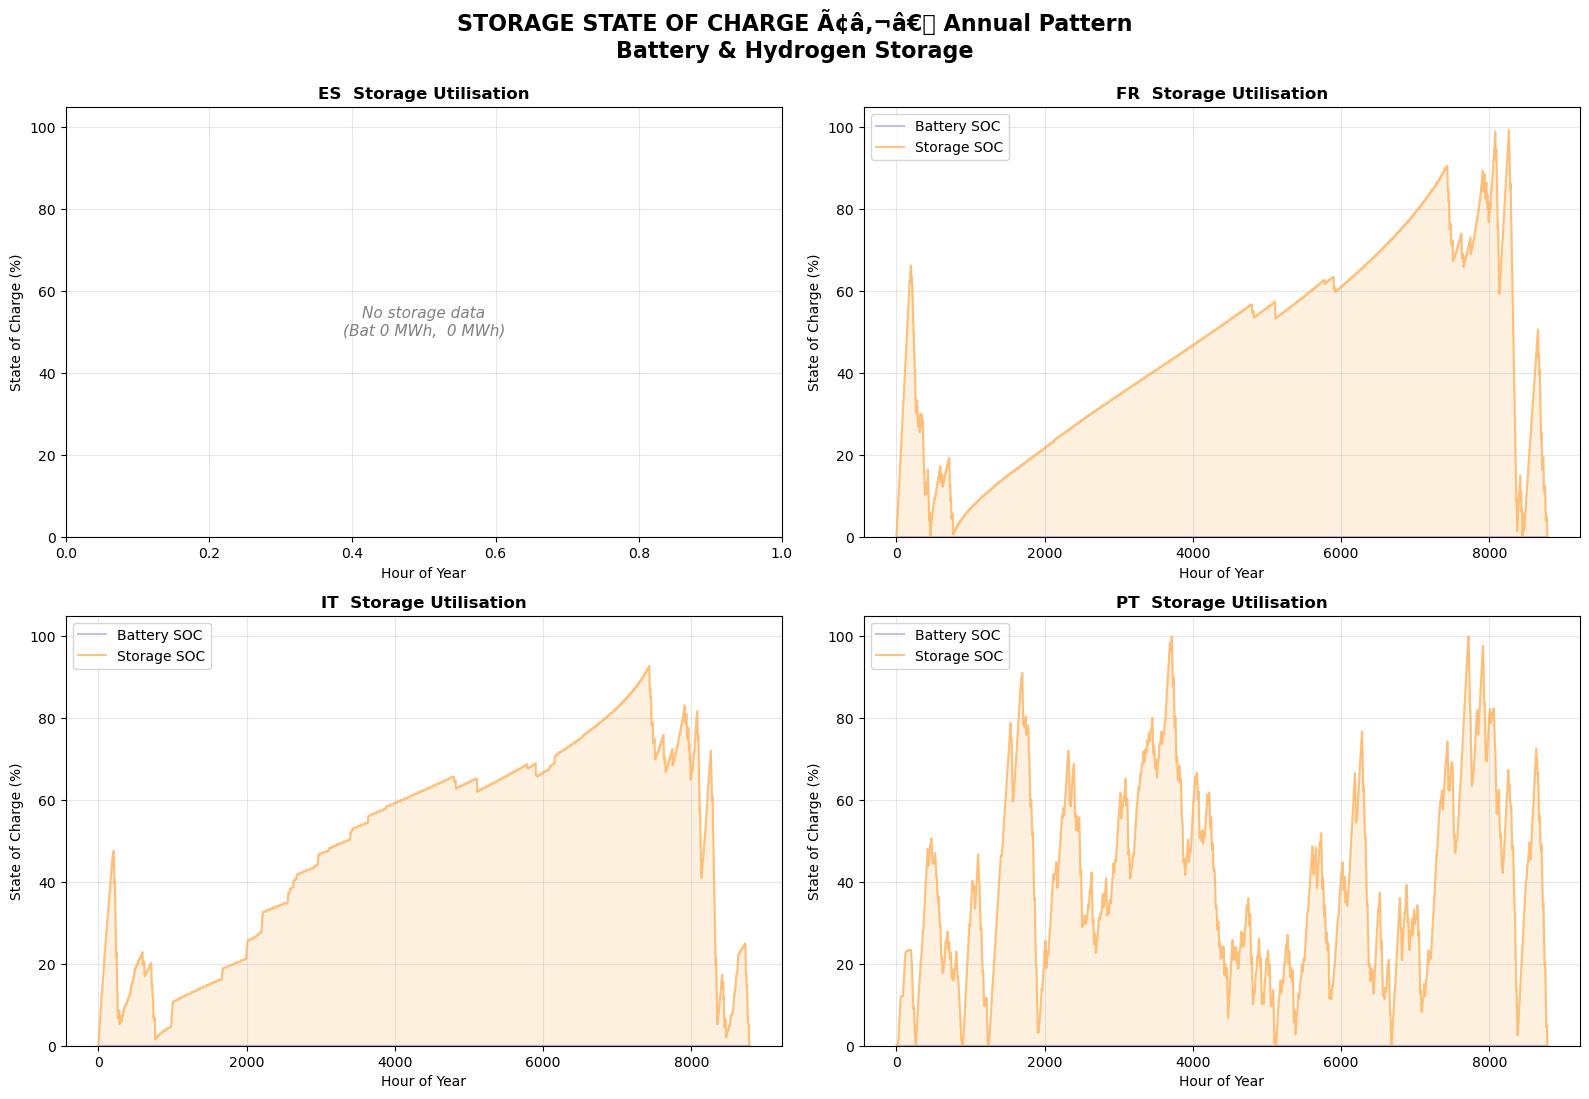

Plot saved: Plots/5_Storage_utilization_battery_H2.png

INTEGRATED ELECTRICITY + H2 OPTIMIZATION - ANALYSIS COMPLETE
Total Annual Cost : 5,653,346,693
Countries         : ES, FR, IT, PT


In [23]:
# =========================================================================
# PLOT: STORAGE UTILIZATION  Battery & H2 Storage State of Charge
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'STORAGE STATE OF CHARGE Ã¢â‚¬â€ Annual Pattern\nBattery & Hydrogen Storage',
    fontsize=16, fontweight='bold', y=0.995
)

for idx, country in enumerate(results_integrated_h2.countries):
    ax = axes[idx // 2, idx % 2]

    batt_name   = f"battery_{country}"
    h2stor_name = f"h2_storage_{country}"
    n_hours     = len(results_integrated_h2.network.snapshots)

    # State-of-charge time series
    batt_soc = np.zeros(n_hours)
    h2_soc   = np.zeros(n_hours)

    soc_t = results_integrated_h2.network.storage_units_t
    if hasattr(soc_t, 'state_of_charge'):
        if batt_name in soc_t.state_of_charge.columns:
            batt_soc = soc_t.state_of_charge[batt_name].values
        if h2stor_name in soc_t.state_of_charge.columns:
            h2_soc = soc_t.state_of_charge[h2stor_name].values

    # Normalise to %
    caps = results_integrated_h2.storage_capacities[country]
    batt_cap = caps.get('Battery_energy', 0)
    h2_cap   = caps.get('H2_storage_energy', 0)

    batt_pct = (batt_soc / batt_cap * 100) if batt_cap > 0 else np.zeros(n_hours)
    h2_pct   = (h2_soc   / h2_cap   * 100) if h2_cap   > 0 else np.zeros(n_hours)

    hours = np.arange(n_hours)
    has_data = batt_pct.any() or h2_pct.any()

    if has_data:
        ax.plot(hours, batt_pct, lw=1.5, label='Battery SOC', color='#BEAED4', alpha=0.8)
        ax.plot(hours, h2_pct,   lw=1.5, label='Storage SOC', color='#FDB462', alpha=0.8)
        ax.fill_between(hours, batt_pct, alpha=0.2, color='#BEAED4')
        ax.fill_between(hours, h2_pct,   alpha=0.2, color='#FDB462')
        ax.legend(fontsize=10)
    else:
        ax.text(
            0.5, 0.5,
            f'No storage data\n(Bat {batt_cap:.0f} MWh,  {h2_cap:.0f} MWh)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=11, style='italic', color='gray'
        )

    ax.set_title(f'{country}  Storage Utilisation', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Year', fontsize=10)
    ax.set_ylabel('State of Charge (%)', fontsize=10)
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
import os
os.makedirs('Plots', exist_ok=True)
plt.savefig('Plots/5_Storage_utilization_battery_H2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: Plots/5_Storage_utilization_battery_H2.png")
print("\n" + "="*80)
print("INTEGRATED ELECTRICITY + H2 OPTIMIZATION - ANALYSIS COMPLETE")
print("="*80)
print(f"Total Annual Cost : {results_integrated_h2.objective_value:,.0f}")
print(f"Countries         : {', '.join(results_integrated_h2.countries)}")


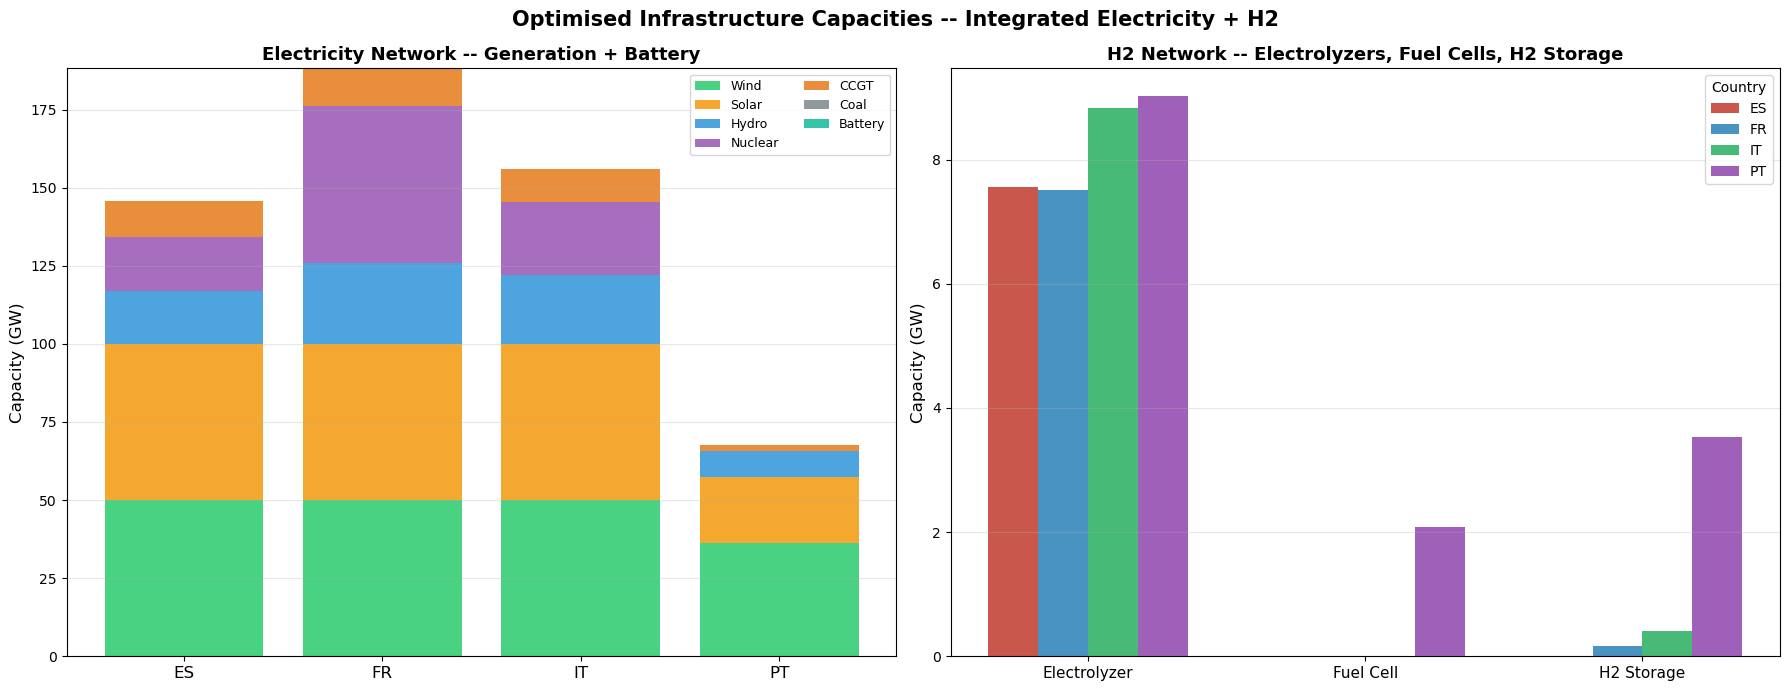

Saved: Plots/IH2_01_Capacities.png


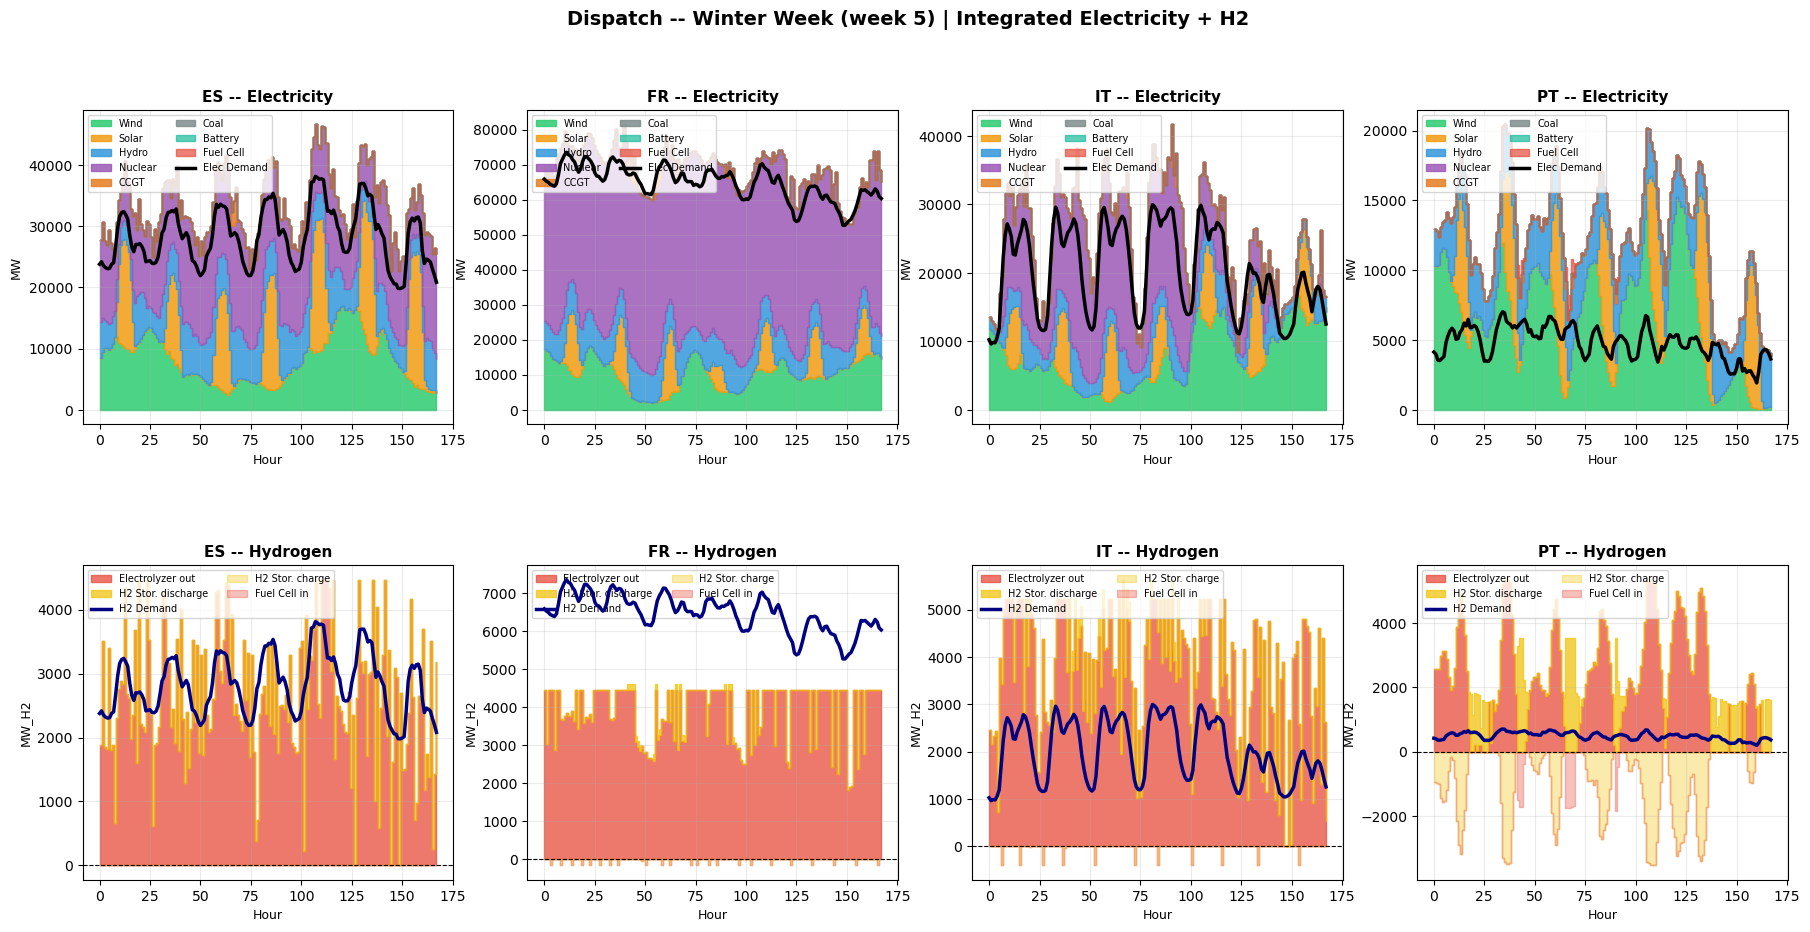

Saved: Plots/IH2_02_Dispatch_Winter.png


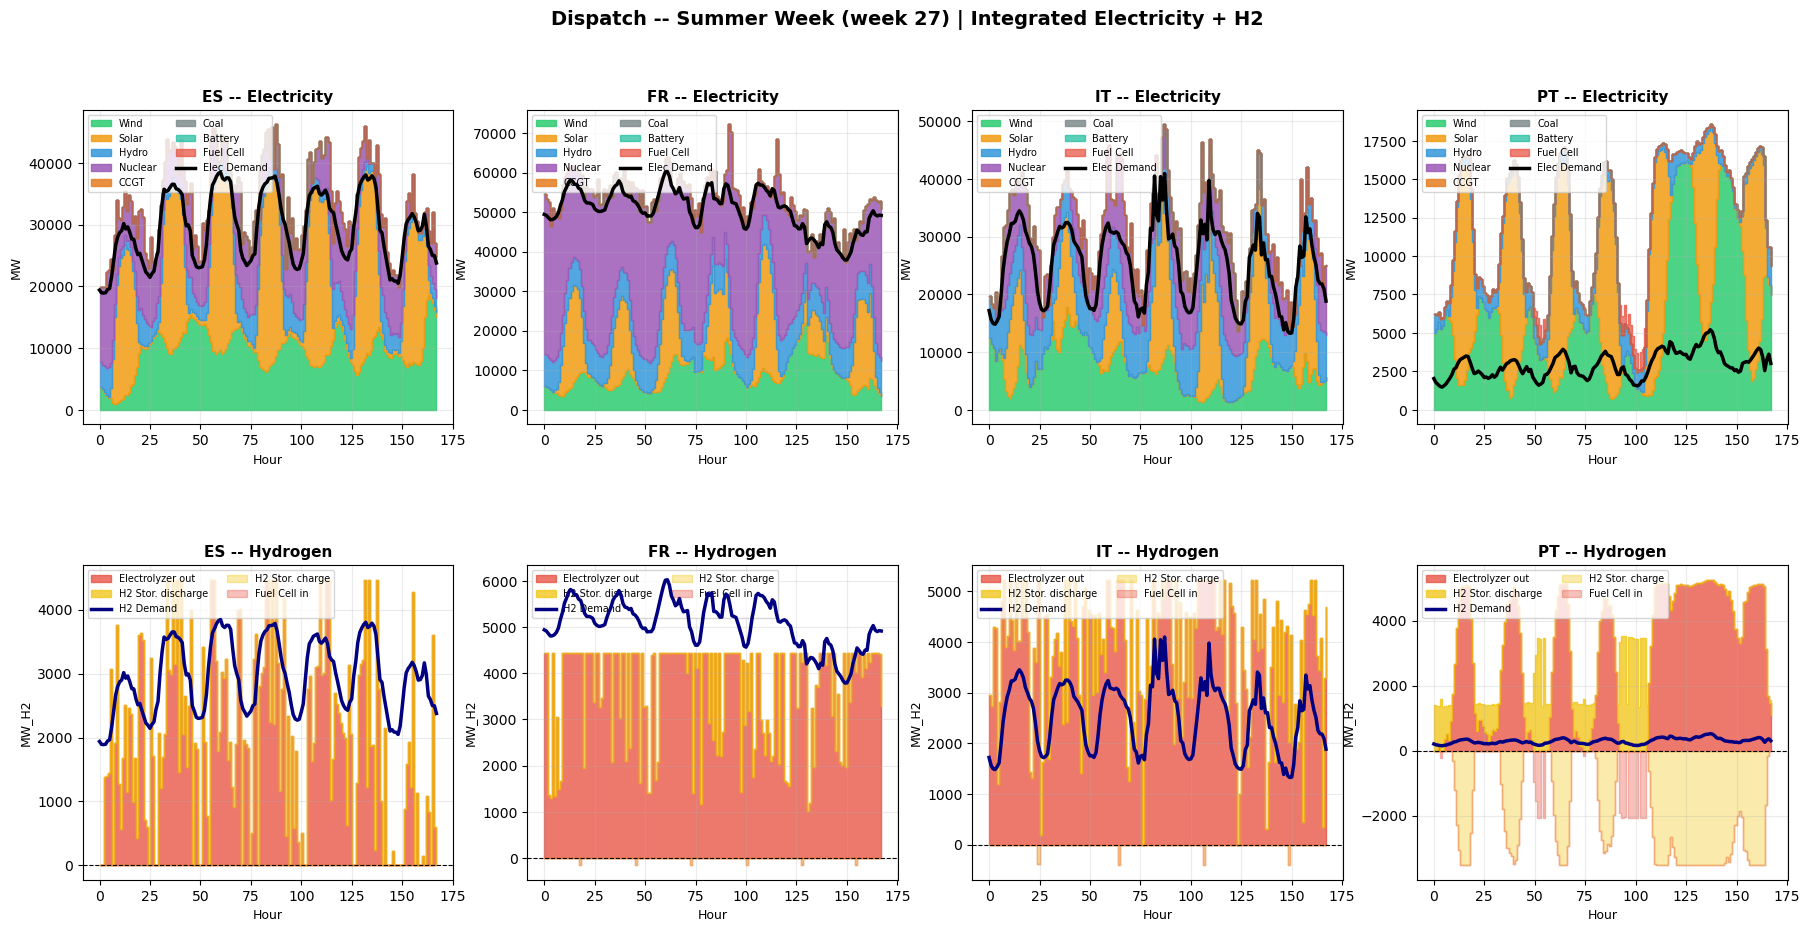

Saved: Plots/IH2_02_Dispatch_Summer.png


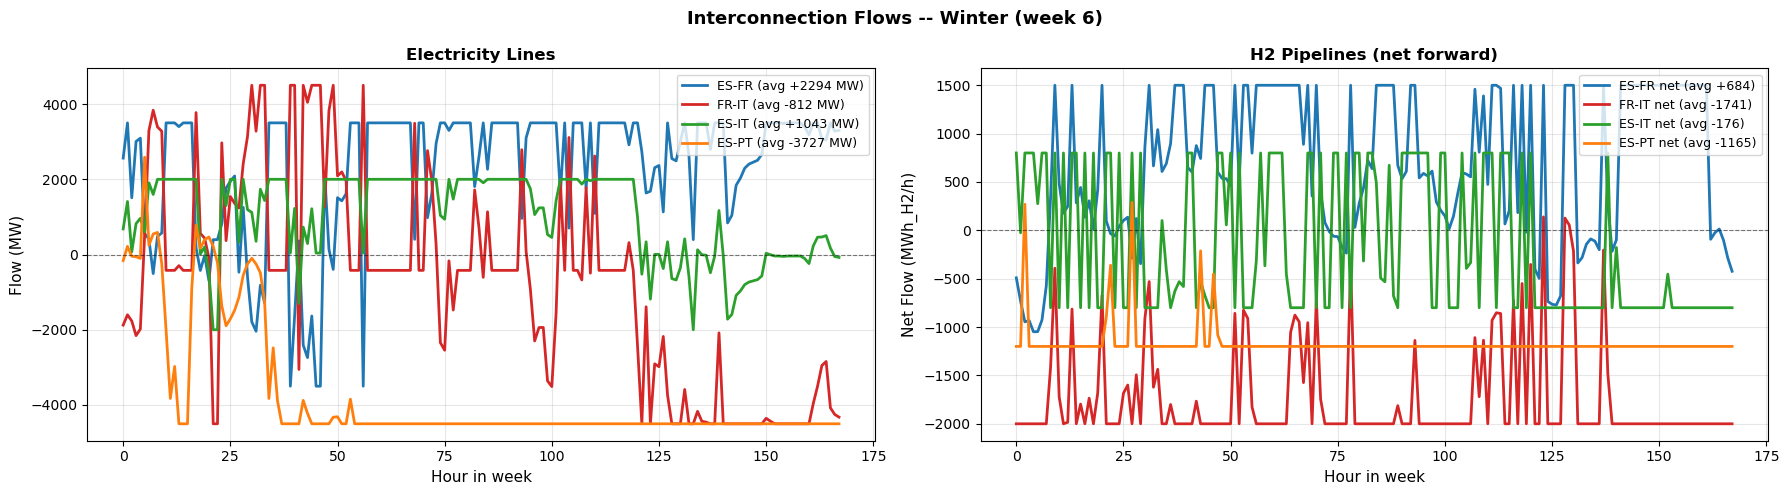

Saved: Plots/IH2_03_Flows_Winter.png


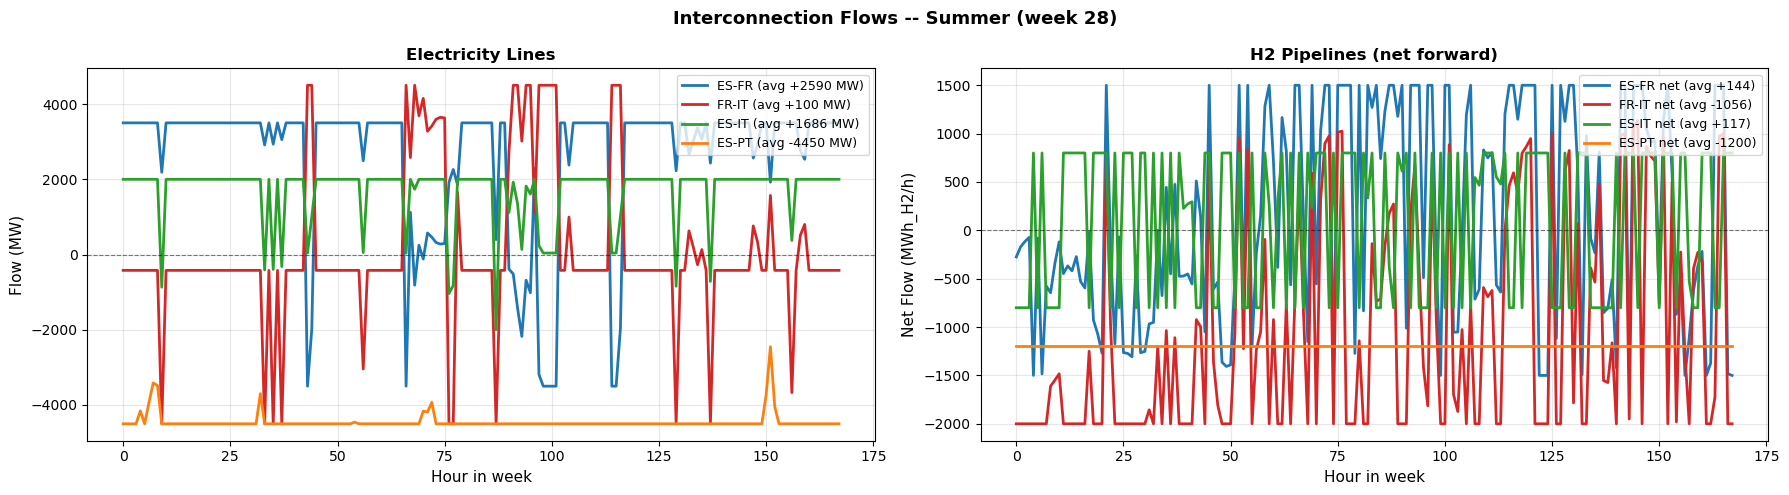

Saved: Plots/IH2_03_Flows_Summer.png


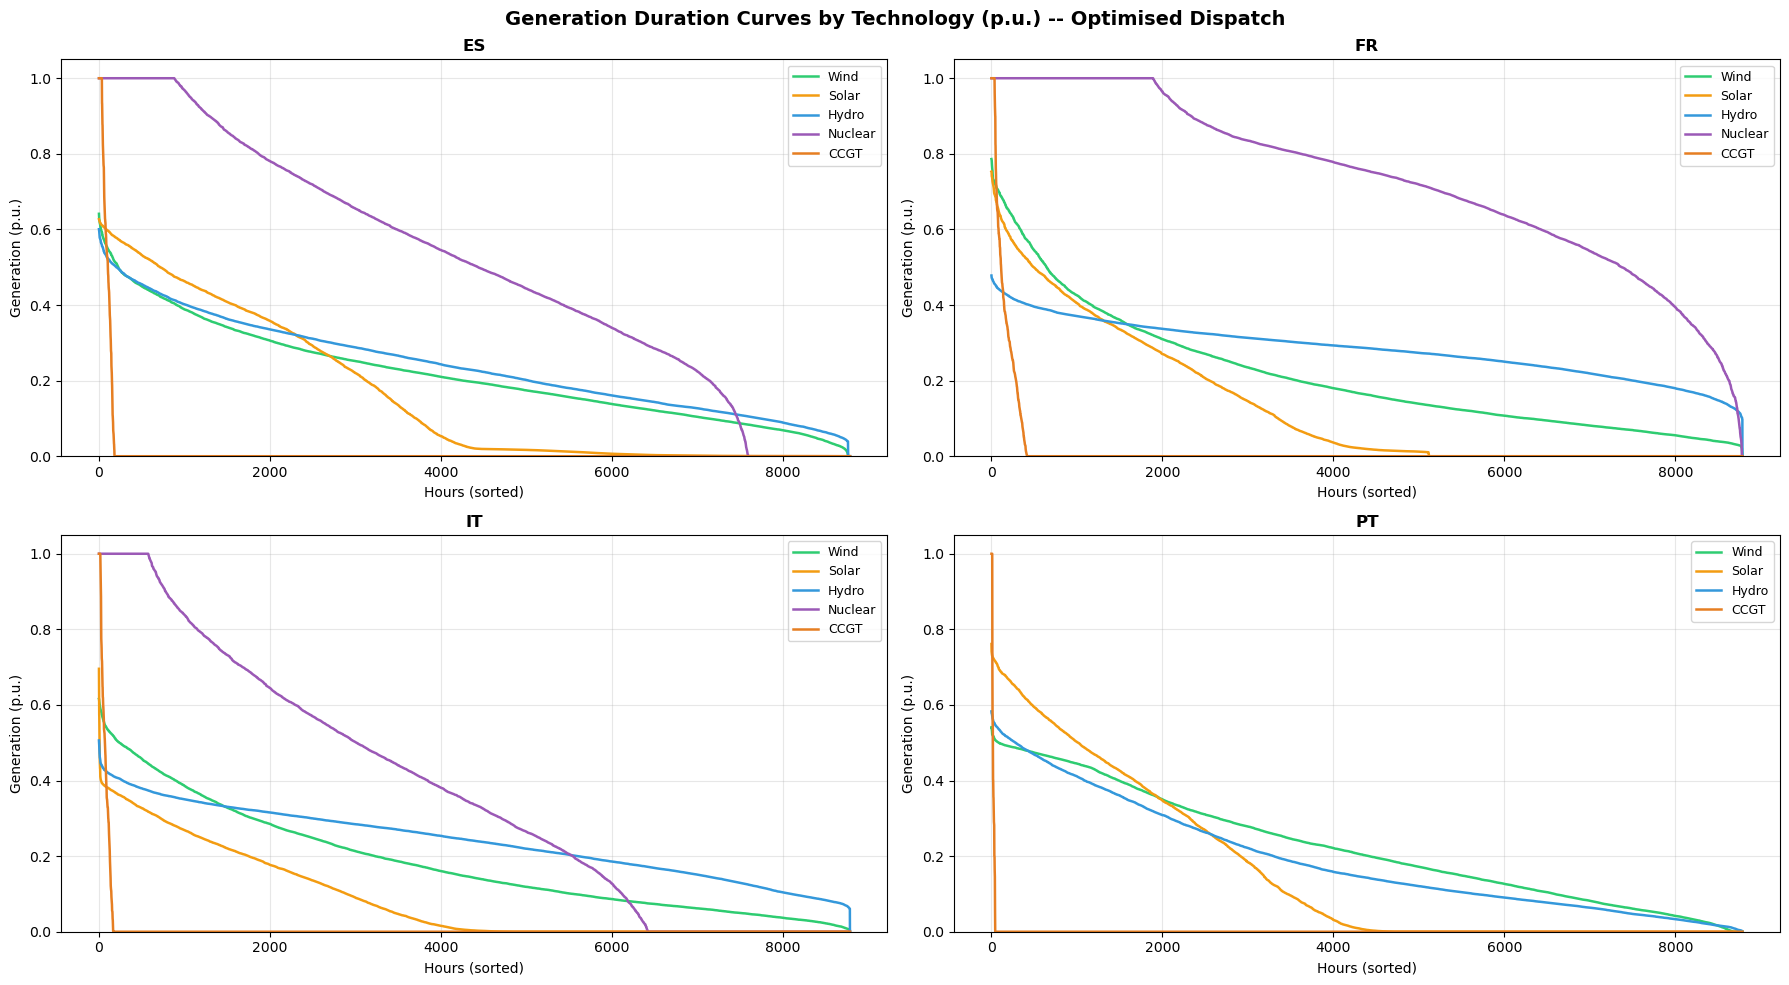

Saved: Plots/IH2_04_GenDurationCurves.png


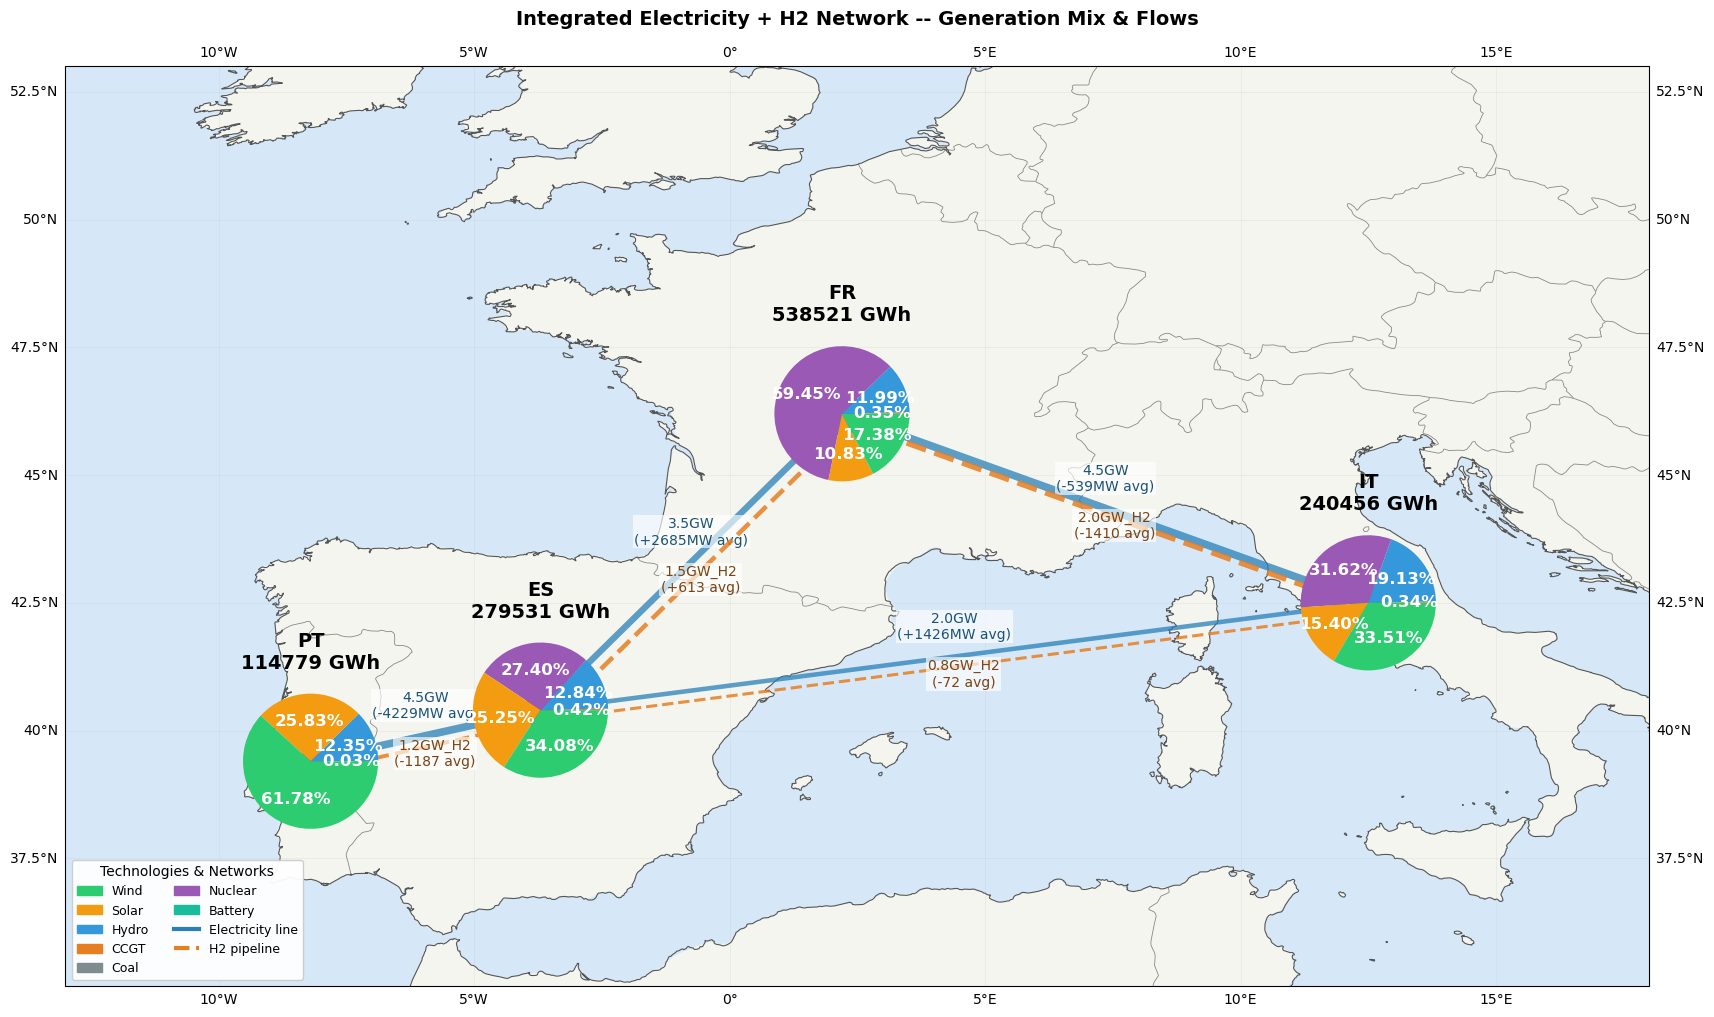

Saved: Plots/IH2_05_Map.png


In [24]:
# =====================================================================
# PLOT 1 -- OPTIMISED CAPACITIES
# Left : electricity generation + battery stacked bar per country
# Right: H2 infrastructure (electrolyzer, fuel cell, H2 storage) per country
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import os; os.makedirs('Plots', exist_ok=True)

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
    'Battery': '#1abc9c',
}
COUNTRY_COLORS = {'ES': '#c0392b', 'FR': '#2980b9', 'IT': '#27ae60', 'PT': '#8e44ad'}

# Build electricity generation capacities per country
elec_caps = {c: {} for c in COUNTRIES}
for gen_name, row in _gen_df.iterrows():
    for c in COUNTRIES:
        if gen_name.startswith(f'gen_{c}_'):
            tech = gen_name.replace(f'gen_{c}_', '')
            elec_caps[c][tech] = row[_cap_col]

for c in COUNTRIES:
    elec_caps[c]['Battery'] = res.storage_capacities[c]['Battery_power']

# H2 infrastructure
h2_infra = {c: {
    'Electrolyzer': res.storage_capacities[c]['Electrolyzer'],
    'Fuel Cell':    res.storage_capacities[c]['Fuel_cell'],
    'H2 Storage':  res.storage_capacities[c]['H2_storage_power'],
} for c in COUNTRIES}

_COST_ORDER = ['Wind', 'Solar', 'Hydro', 'Nuclear', 'CCGT', 'Coal', 'Battery']
all_elec_techs = sorted({t for d in elec_caps.values() for t in d},
                         key=lambda t: _COST_ORDER.index(t) if t in _COST_ORDER else len(_COST_ORDER))
h2_tech_labels = ['Electrolyzer', 'Fuel Cell', 'H2 Storage']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Optimised Infrastructure Capacities -- Integrated Electricity + H2',
             fontsize=15, fontweight='bold')

# Stacked bar: electricity + battery
x_c = np.arange(len(COUNTRIES))
bottom = np.zeros(len(COUNTRIES))
for tech in all_elec_techs:
    vals = [elec_caps[c].get(tech, 0) / 1e3 for c in COUNTRIES]
    ax1.bar(x_c, vals, bottom=bottom, label=tech,
            color=TECH_COLORS.get(tech, '#bdc3c7'), alpha=0.88)
    bottom += np.array(vals)
ax1.set_xticks(x_c); ax1.set_xticklabels(COUNTRIES, fontsize=12)
ax1.set_ylabel('Capacity (GW)', fontsize=12)
ax1.set_title('Electricity Network -- Generation + Battery', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, ncol=2, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Grouped bar: H2 infrastructure
x_t = np.arange(len(h2_tech_labels))
width = 0.18
for idx, c in enumerate(COUNTRIES):
    vals = [h2_infra[c].get(t, 0) / 1e3 for t in h2_tech_labels]
    ax2.bar(x_t + idx * width, vals, width, label=c,
            color=COUNTRY_COLORS.get(c, '#bdc3c7'), alpha=0.85)
ax2.set_xticks(x_t + width * 1.5)
ax2.set_xticklabels(h2_tech_labels, fontsize=11)
ax2.set_ylabel('Capacity (GW)', fontsize=12)
ax2.set_title('H2 Network -- Electrolyzers, Fuel Cells, H2 Storage', fontsize=13, fontweight='bold')
ax2.legend(title='Country', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Plots/IH2_01_Capacities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/IH2_01_Capacities.png")

# PLOT2 
# =====================================================================
# PLOT 2 -- GENERATION + H2 DISPATCH: REPRESENTATIVE WEEKS
# Top row: electricity stacked area + demand line (4 countries)
# Bottom row: H2 production/consumption stacked area + H2 demand line
# Shown for Winter (week 5) and Summer (week 27)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
}
ORDERED = ['Wind', 'Solar', 'Hydro', 'Nuclear', 'CCGT', 'Coal']

for season_name, week_num in [('Winter', 5), ('Summer', 27)]:
    h0 = (week_num - 1) * 168
    h1 = h0 + 168
    x  = np.arange(168)

    fig, axes = plt.subplots(2, len(COUNTRIES), figsize=(22, 10),
                             gridspec_kw={'hspace': 0.45})
    fig.suptitle(
        f'Dispatch -- {season_name} Week (week {week_num}) | Integrated Electricity + H2',
        fontsize=14, fontweight='bold'
    )

    for col, country in enumerate(COUNTRIES):
        ax_e = axes[0, col]
        ax_h = axes[1, col]
        bottom_e = np.zeros(168)

        # -- Electricity: generation stacked area --
        for tech in ORDERED:
            gen_name = f'gen_{country}_{tech}'
            if gen_name in network.generators_t.p.columns:
                vals = network.generators_t.p[gen_name].iloc[h0:h1].values
                ax_e.fill_between(x, bottom_e, bottom_e + vals, step='post',
                                  label=tech, color=TECH_COLORS.get(tech,'#bdc3c7'), alpha=0.85)
                bottom_e += vals

        # Battery discharge
        batt = f'battery_{country}'
        if batt in network.storage_units_t.p.columns:
            dis = network.storage_units_t.p[batt].iloc[h0:h1].clip(lower=0).values
            ax_e.fill_between(x, bottom_e, bottom_e + dis, step='post',
                              label='Battery', color='#1abc9c', alpha=0.7)
            bottom_e += dis

        # Fuel cell -> electricity output (p1 negative -> abs)
        fc = f'fuel_cell_{country}'
        if fc in network.links_t.p1.columns:
            fc_out = network.links_t.p1[fc].iloc[h0:h1].abs().values
            ax_e.fill_between(x, bottom_e, bottom_e + fc_out, step='post',
                              label='Fuel Cell', color='#e74c3c', alpha=0.7)
            bottom_e += fc_out

        # Electricity demand line
        dem = f'demand_elec_{country}'
        dem_vals = (network.loads_t.p_set[dem].iloc[h0:h1].values
                    if dem in network.loads_t.p_set.columns else np.zeros(168))
        ax_e.plot(x, dem_vals, color='black', lw=2.5, label='Elec Demand', zorder=10)
        ax_e.set_title(f'{country} -- Electricity', fontsize=11, fontweight='bold')
        ax_e.set_ylabel('MW', fontsize=9); ax_e.set_xlabel('Hour', fontsize=9)
        ax_e.legend(fontsize=7, ncol=2, loc='upper left')
        ax_e.grid(True, alpha=0.25)

        # -- Hydrogen: production / consumption --
        elyz = f'electrolyzer_{country}'
        elyz_h2 = (network.links_t.p1[elyz].iloc[h0:h1].abs().values
                   if elyz in network.links_t.p1.columns else np.zeros(168))

        h2s = f'h2_storage_{country}'
        if h2s in network.storage_units_t.p.columns:
            h2s_dis = network.storage_units_t.p[h2s].iloc[h0:h1].clip(lower=0).values
            h2s_ch  = network.storage_units_t.p[h2s].iloc[h0:h1].clip(upper=0).abs().values
        else:
            h2s_dis = h2s_ch = np.zeros(168)

        fc_h2_in = (network.links_t.p0[fc].iloc[h0:h1].values
                    if fc in network.links_t.p0.columns else np.zeros(168))

        h2dem = f'demand_h2_{country}'
        h2_dem_vals = (network.loads_t.p_set[h2dem].iloc[h0:h1].values
                       if h2dem in network.loads_t.p_set.columns else np.zeros(168))

        b2 = np.zeros(168)
        ax_h.fill_between(x, b2, b2 + elyz_h2, step='post',
                          label='Electrolyzer out', color='#e74c3c', alpha=0.75)
        b2 += elyz_h2
        ax_h.fill_between(x, b2, b2 + h2s_dis, step='post',
                          label='H2 Stor. discharge', color='#f1c40f', alpha=0.75)
        ax_h.plot(x, h2_dem_vals, color='navy', lw=2.5, label='H2 Demand', zorder=10)
        ax_h.fill_between(x, -h2s_ch, step='post',
                          label='H2 Stor. charge', color='#f1c40f', alpha=0.35)
        ax_h.fill_between(x, -h2s_ch - fc_h2_in, -h2s_ch, step='post',
                          label='Fuel Cell in', color='#e74c3c', alpha=0.35)
        ax_h.axhline(0, color='black', lw=0.8, ls='--')
        ax_h.set_title(f'{country} -- Hydrogen', fontsize=11, fontweight='bold')
        ax_h.set_ylabel('MW_H2', fontsize=9); ax_h.set_xlabel('Hour', fontsize=9)
        ax_h.legend(fontsize=7, ncol=2, loc='upper left')
        ax_h.grid(True, alpha=0.25)

    fname = f'Plots/IH2_02_Dispatch_{season_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# PLOT3
# =====================================================================
# PLOT 3 -- INTERCONNECTION FLOWS: ELECTRICITY vs H2 PIPELINES
# Side-by-side per season: electricity line flows (MW) | H2 net flows (MWh_H2/h)
# Same colour per route in both panels for easy comparison
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

res = results_integrated_h2

COLORS_ROUTE = {
    'ES-FR': '#1f77b4', 'ES-PT': '#ff7f0e',
    'ES-IT': '#2ca02c', 'FR-IT': '#d62728',
}

def week_of_hour(h): return int(h) // 168 + 1

elec_flows = res.power_flows.copy()
h2_flows   = res.h2_flows.copy()
elec_flows['week'] = elec_flows['hour'].apply(week_of_hour)
h2_flows['week']   = h2_flows['hour'].apply(week_of_hour)

for season_name, sel_week in [('Winter', 6), ('Summer', 28)]:
    ef = elec_flows[elec_flows['week'] == sel_week]
    hf = h2_flows[h2_flows['week']   == sel_week]

    fig, (ax_e, ax_h) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(
        f'Interconnection Flows -- {season_name} (week {sel_week})',
        fontsize=13, fontweight='bold'
    )

    # Electricity
    for from_c, to_c in ef[['from','to']].drop_duplicates().values:
        mask = (ef['from'] == from_c) & (ef['to'] == to_c)
        df   = ef[mask].sort_values('hour')
        rname = f'{from_c}-{to_c}'
        col   = COLORS_ROUTE.get(rname, COLORS_ROUTE.get(f'{to_c}-{from_c}', 'gray'))
        avg   = df['flow_mw'].mean()
        ax_e.plot(range(len(df)), df['flow_mw'].values, lw=2,
                  label=f'{rname} (avg {avg:+.0f} MW)', color=col)
    ax_e.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax_e.set_xlabel('Hour in week', fontsize=11); ax_e.set_ylabel('Flow (MW)', fontsize=11)
    ax_e.set_title('Electricity Lines', fontsize=12, fontweight='bold')
    ax_e.legend(fontsize=9, loc="upper right"); ax_e.grid(True, alpha=0.3)

    # H2 pipelines (net forward flow)
    for from_c, to_c in hf[['from','to']].drop_duplicates().values:
        mask = (hf['from'] == from_c) & (hf['to'] == to_c)
        df   = hf[mask].sort_values('hour')
        rname = f'{from_c}-{to_c}'
        col   = COLORS_ROUTE.get(rname, COLORS_ROUTE.get(f'{to_c}-{from_c}', 'gray'))
        net   = df['flow_mwh_h2_net'].values
        avg   = net.mean()
        ax_h.plot(range(len(df)), net, lw=2,
                  label=f'{rname} net (avg {avg:+.0f})', color=col)
    ax_h.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax_h.set_xlabel('Hour in week', fontsize=11)
    ax_h.set_ylabel('Net Flow (MWh_H2/h)', fontsize=11)
    ax_h.set_title('H2 Pipelines (net forward)', fontsize=12, fontweight='bold')
    ax_h.legend(fontsize=9,loc="upper right"); ax_h.grid(True, alpha=0.3)

    fname = f'Plots/IH2_03_Flows_{season_name}.png'
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


# PLOT4
# =====================================================================
# PLOT 4 -- GENERATION DURATION CURVES BY TECHNOLOGY (p.u.)
# Sorted descending generation profile for each tech, per country
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
}
ORDERED = ['Wind', 'Solar', 'Hydro', 'Nuclear', 'CCGT', 'Coal']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Generation Duration Curves by Technology (p.u.) -- Optimised Dispatch',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for col, country in enumerate(COUNTRIES):
    ax = axes[col]
    for tech in ORDERED:
        gen_name = f'gen_{country}_{tech}'
        if gen_name not in network.generators_t.p.columns:
            continue
        cap = _gen_df.loc[gen_name, _cap_col] if gen_name in _gen_df.index else 0
        if cap <= 0:
            continue
        gen_vals = network.generators_t.p[gen_name].values
        pu = np.sort(gen_vals / cap)[::-1]
        ax.plot(pu, lw=1.8, label=tech, color=TECH_COLORS.get(tech, 'gray'))

    ax.set_title(f'{country}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours (sorted)', fontsize=10)
    ax.set_ylabel('Generation (p.u.)', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Plots/IH2_04_GenDurationCurves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/IH2_04_GenDurationCurves.png")


# PLOT5
# =====================================================================
# PLOT 5 -- GEOGRAPHIC MAP: ELECTRICITY + H2 NETWORKS
# Blue solid lines  = electricity interconnections (width ~ NTC)
# Orange dashed lines = H2 pipelines (width ~ H2 capacity)
# Pie chart insets  = annual generation mix per country
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

COORDS = {'ES': (40.4, -3.7), 'FR': (46.2,  2.2),
          'IT': (42.5, 12.5), 'PT': (39.4, -8.2)}

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
    'Battery': '#1abc9c',
}
COUNTRY_COLORS = {'ES': '#c0392b', 'FR': '#2980b9', 'IT': '#27ae60', 'PT': '#8e44ad'}

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

# Annual generation per country per tech
annual_gen = {c: {} for c in COUNTRIES}
for gen_name in _gen_df.index:
    for c in COUNTRIES:
        if gen_name.startswith(f'gen_{c}_'):
            tech = gen_name.replace(f'gen_{c}_', '')
            if gen_name in network.generators_t.p.columns:
                annual_gen[c][tech] = network.generators_t.p[gen_name].sum()

# Interconnection NTC (MW) and H2 pipeline capacities (MW_H2)
ELEC_LINES = [('ES','FR',3500), ('FR','IT',4500), ('ES','IT',2000), ('ES','PT',4500)]
H2_CAPS = {}
for name, row in network.links.iterrows():
    if name.startswith('h2_pipe_'):
        parts = name.split('_')
        from_c, to_c = parts[2], parts[3]
        H2_CAPS[(from_c, to_c)] = row['p_nom']

# Mean hourly flows
elec_net = {(f, t): grp['flow_mw'].mean()
            for (f, t), grp in res.power_flows.groupby(['from','to'])}
h2_net   = {(f, t): grp['flow_mwh_h2_net'].mean()
            for (f, t), grp in res.h2_flows.groupby(['from','to'])}

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig  = plt.figure(figsize=(18, 13))
    ax   = fig.add_axes([0.05, 0.05, 0.88, 0.88], projection=proj)
    ax.set_extent([-13, 18, 35, 53], crs=proj)
    ax.add_feature(cfeature.LAND,   facecolor='#f5f5f0')
    ax.add_feature(cfeature.OCEAN,  facecolor='#d6e8f7')
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='#888')
    ax.coastlines(resolution='10m', linewidth=0.8, color='#555')
    ax.gridlines(draw_labels=True, alpha=0.2, linewidth=0.5)

    # Electricity lines (blue solid, width ~ NTC)
    for from_c, to_c, ntc in ELEC_LINES:
        if from_c not in COORDS or to_c not in COORDS: continue
        lat1, lon1 = COORDS[from_c]; lat2, lon2 = COORDS[to_c]
        lw  = 1.5 + 4 * ntc / 4500
        avg = elec_net.get((from_c, to_c), elec_net.get((to_c, from_c), 0))
        ax.plot([lon1, lon2], [lat1, lat2], color='#2980b9', lw=lw,
                alpha=0.75, transform=proj, zorder=3)
        mx, my = (lon1+lon2)/2, (lat1+lat2)/2
        ax.text(mx, my+0.35, f'{ntc/1e3:.1f}GW\n({avg:+.0f}MW avg)',
                transform=proj, fontsize=10, ha='center', color='#1a5276',
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    # H2 pipelines (orange dashed, width ~ H2 cap, slightly offset)
    drawn = set()
    for (from_c, to_c), cap in H2_CAPS.items():
        key = tuple(sorted([from_c, to_c]))
        if key in drawn or from_c not in COORDS or to_c not in COORDS: continue
        drawn.add(key)
        lat1, lon1 = COORDS[from_c]; lat2, lon2 = COORDS[to_c]
        lw  = 1.0 + 3 * cap / 2000
        off = 0.18
        net = h2_net.get((from_c, to_c), h2_net.get((to_c, from_c), 0))
        ax.plot([lon1+off, lon2+off], [lat1-off, lat2-off],
                color='#e67e22', lw=lw, ls='--', alpha=0.85,
                transform=proj, zorder=3)
        mx, my = (lon1+lon2)/2+off, (lat1+lat2)/2-off
        ax.text(mx, my-0.4, f'{cap/1e3:.1f}GW_H2\n({net:+.0f} avg)',
                transform=proj, fontsize=10, ha='center', color='#784212',
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    # Country nodes
    for c in COUNTRIES:
        if c not in COORDS: continue
        lat, lon = COORDS[c]
        total = sum(_gen_df.loc[n, _cap_col]
                    for n in _gen_df.index if n.startswith(f'gen_{c}_'))
        ms = 12 + 22 * total / 200e3
        ax.plot(lon, lat, 'o', markersize=ms, color=COUNTRY_COLORS.get(c,'gray'),
                transform=proj, zorder=5, markeredgecolor='white', markeredgewidth=2)
        #ax.text(lon, lat+1.3, c, transform=proj, fontsize=13,
               # fontweight='bold', ha='center')

    # Pie chart insets at country nodes
    ax_pos = ax.get_position()
    LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -13, 18, 35, 53
    SZ = 0.13

    for c in COUNTRIES:
        if c not in COORDS or not annual_gen[c]: continue
        lat, lon = COORDS[c]
        rel_x = (lon - LON_MIN) / (LON_MAX - LON_MIN)
        rel_y = (lat - LAT_MIN) / (LAT_MAX - LAT_MIN)
        fx = ax_pos.x0 + rel_x * ax_pos.width  - SZ / 2
        fy = ax_pos.y0 + rel_y * ax_pos.height - SZ / 2
        ax_i = fig.add_axes([fx, fy, SZ, SZ])
        data = {t: v for t, v in annual_gen[c].items() if v > 0}
        if not data: continue
        _, _, auts = ax_i.pie(
            list(data.values()),
            colors=[TECH_COLORS.get(t,'#bdc3c7') for t in data],
            autopct='%3.2f%%', textprops={'fontsize': 8}
        )
        for at in auts:
            at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(12)
        gwh = sum(data.values()) / 1e3
        ax_i.set_title(f'{c}\n{gwh:.0f} GWh', fontsize=14, fontweight='bold')

    # Legend
    tech_p = [mpatches.Patch(color=TECH_COLORS.get(t,'gray'), label=t)
              for t in ['Wind','Solar','Hydro','CCGT','Coal','Nuclear','Battery']]
    el_ln  = mlines.Line2D([], [], color='#2980b9', lw=3, label='Electricity line')
    h2_ln  = mlines.Line2D([], [], color='#e67e22', lw=3, ls='--', label='H2 pipeline')
    ax.legend(handles=tech_p + [el_ln, h2_ln], loc='lower left',
              fontsize=9, framealpha=0.95, ncol=2,
              title='Technologies & Networks', title_fontsize=10)
    ax.set_title('Integrated Electricity + H2 Network -- Generation Mix & Flows',
                 fontsize=14, fontweight='bold', pad=15)

else:
    # Schematic fallback if cartopy not installed
    fig, ax = plt.subplots(figsize=(10, 8))
    POS = {'ES': (0.22, 0.38), 'FR': (0.52, 0.72), 'IT': (0.78, 0.40), 'PT': (0.06, 0.28)}
    for from_c, to_c, ntc in ELEC_LINES:
        x1,y1 = POS[from_c]; x2,y2 = POS[to_c]
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))
    for (from_c, to_c), cap in H2_CAPS.items():
        x1,y1 = POS.get(from_c,(0,0)); x2,y2 = POS.get(to_c,(0,0))
        ax.plot([x1,x2],[y1,y2], '--', color='#e67e22', lw=2, alpha=0.7)
    for c, (x,y) in POS.items():
        ax.text(x, y, c, ha='center', va='center', fontsize=18, fontweight='bold',
                color=COUNTRY_COLORS.get(c,'gray'),
                bbox=dict(boxstyle='circle,pad=0.5', facecolor='white', edgecolor='gray'))
    el_ln = mlines.Line2D([],[],color='#2980b9', label='Electricity lines')
    h2_ln = mlines.Line2D([],[],color='#e67e22', ls='--', label='H2 pipelines')
    ax.legend(handles=[el_ln, h2_ln], fontsize=11)
    ax.set_title('Integrated Network (schematic -- install cartopy for map)', fontsize=12)
    ax.axis('off')

plt.savefig('Plots/IH2_05_Map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/IH2_05_Map.png")

In [24]:
# =====================================================================
# CO2 DECARBONISATION ANALYSIS
# =====================================================================
# Target: 50% CO2 reduction from the unconstrained baseline
# (broadly consistent with EU Fit-for-55: 62% ETS-sector reduction vs 2005)
#
# Method:
#   1. Compute baseline CO2 from the already-solved results_integrated_h2
#   2. Re-run the full capacity-expansion + dispatch optimisation with a
#      system-wide CO2 cap → the dual variable (shadow price) gives the
#      CO2 price (€/tCO2) required to achieve that decarbonisation level
#
# Emission factors (EEA EMEP/EEA Guidebook 2023, direct combustion):
#   Coal : 94.6 kgCO2/GJ_fuel / 0.38 η = 0.896 tCO2/MWh_e
#   CCGT : 56.1 kgCO2/GJ_fuel / 0.55 η = 0.367 tCO2/MWh_e
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from python_codes.co2_analysis import (
    EMISSION_FACTORS,
    CO2Result,
    compute_baseline_co2,
    run_co2_constrained,
    sweep_co2_targets,
)

# --- Step 1: Baseline CO2 from unconstrained result ---
baseline_co2 = compute_baseline_co2(results_integrated_h2)
print(f"Baseline CO2 emissions : {baseline_co2 / 1e6:.3f} Mt CO2/year")
print(f"  Breakdown by technology:")
network_base = results_integrated_h2.network
for tech, ef in EMISSION_FACTORS.items():
    tech_co2 = 0.0
    for c in results_integrated_h2.countries:
        col = f"gen_{c}_{tech}"
        if col in network_base.generators_t.p.columns:
            tech_co2 += network_base.generators_t.p[col].sum() * ef
    print(f"    {tech}: {tech_co2 / 1e6:.3f} Mt CO2/year")

# --- Step 2: Choose decarbonisation target (50% reduction) ---
TARGET_REDUCTION = 0.50   # 50% reduction from baseline
co2_limit = baseline_co2 * (1.0 - TARGET_REDUCTION)
print(f"\nCO2 target ({TARGET_REDUCTION*100:.0f}% reduction): {co2_limit / 1e6:.3f} Mt CO2/year")

# --- Step 3: Shared kwargs (same parameters as the baseline run, cell 30) ---
_opt_kwargs = dict(
    h2_demand_fraction=0.10,
    h2_pipeline_capacities=h2_pipeline_capacities,
    battery_max_hours=4.0,
    battery_charging_efficiency=_bat_eta,
    battery_discharging_efficiency=_bat_eta,
    battery_fixed_cost=battery_fixed_cost,
    battery_max_capacity_limit=100_000.0,
    hydrogen_max_hours=168.0,
    hydrogen_charging_efficiency=_h2_eta,
    hydrogen_discharging_efficiency=_h2_eta,
    hydrogen_fixed_cost=hydrogen_fixed_cost,
    hydrogen_max_capacity_limit=100_000.0,
    electrolyzer_efficiency=_h2_eta,
    fuel_cell_efficiency=_h2_eta,
    electrolyzer_fixed_cost=500.0,
    fuel_cell_fixed_cost=500.0,
    solver_name="gurobi",
)

# --- Step 4: Run CO2-constrained optimisation ---
result_co2 = run_co2_constrained(
    data=data_integrated_h2,
    co2_limit=co2_limit,
    baseline_co2=baseline_co2,
    **_opt_kwargs,
)

Baseline CO2 emissions : 1.447 Mt CO2/year
  Breakdown by technology:
    Coal: 0.000 Mt CO2/year
    CCGT: 1.447 Mt CO2/year

CO2 target (50% reduction): 0.723 Mt CO2/year

CO2-CONSTRAINED INTEGRATED ELECTRICITY + H2 OPTIMIZATION
CO2 cap  : 0.723 Mt CO2/year
Reduction: 50.0% vs baseline (1.447 Mt)

MULTI-COUNTRY INTEGRATED ELECTRICITY + HYDROGEN OPTIMIZATION

Countries    : ['ES', 'FR', 'IT', 'PT']
Technologies : ['CCGT', 'Coal', 'Hydro', 'Nuclear', 'Solar', 'Wind']
H2 demand    : 10.0% of electricity demand per country per hour

Time horizon : 8784 hours

H2 pipeline capacities (user-defined):
  ES → FR: 1,500 MWh_H2/h
  ES → IT: 800 MWh_H2/h
  ES → PT: 1,200 MWh_H2/h
  FR → IT: 2,000 MWh_H2/h

────────────────────────────────────────────────────────────────────────────────
Building dual-bus network (electricity + hydrogen per country)
────────────────────────────────────────────────────────────────────────────────
  ES: buses 'ES_elec'  'ES_h2'
  FR: buses 'FR_elec'  'FR_h2'
  IT: b

Index(['ES_elec', 'ES_h2', 'FR_elec', 'FR_h2', 'IT_elec', 'IT_h2', 'PT_elec', 'PT_h2'], dtype='str', name='name')
Index(['gen_ES_CCGT', 'gen_FR_CCGT', 'gen_IT_CCGT', 'gen_PT_CCGT', 'gen_ES_Coal', 'gen_FR_Coal', 'gen_IT_Coal',
       'gen_PT_Coal', 'gen_ES_Hydro', 'gen_FR_Hydro', 'gen_IT_Hydro', 'gen_PT_Hydro', 'gen_ES_Nuclear',
       'gen_FR_Nuclear', 'gen_IT_Nuclear', 'gen_PT_Nuclear', 'gen_ES_Solar', 'gen_FR_Solar', 'gen_IT_Solar',
       'gen_PT_Solar', 'gen_ES_Wind', 'gen_FR_Wind', 'gen_IT_Wind', 'gen_PT_Wind'],
      dtype='str', name='name')
Index(['electrolyzer_ES', 'electrolyzer_FR', 'electrolyzer_IT', 'electrolyzer_PT', 'fuel_cell_ES', 'fuel_cell_FR',
       'fuel_cell_IT', 'fuel_cell_PT', 'h2_pipe_ES_FR', 'h2_pipe_FR_ES', 'h2_pipe_FR_IT', 'h2_pipe_IT_FR',
       'h2_pipe_ES_IT', 'h2_pipe_IT_ES', 'h2_pipe_ES_PT', 'h2_pipe_PT_ES'],
      dtype='str', name='name')
Index(['battery_ES', 'battery_FR', 'battery_IT', 'battery_PT', 'h2_storage_ES', 'h2_storage_FR', 'h2_storage_IT',
 


  Electrolyzers (elec → H2) added for all countries
  Fuel cells    (H2 → elec) added for all countries
  H2 storage    (on H2 bus) added for all countries
  H2 pipelines  added (8 directions, bidirectional)

  H2 network validation:
    ES: annual=24820.1 GWh_H2, peak=4117.8 MWh_H2/h  [OK]
    FR: annual=51039.0 GWh_H2, peak=8106.6 MWh_H2/h  [OK]
    IT: annual=19319.8 GWh_H2, peak=4152.9 MWh_H2/h  [OK]
    PT: annual=3597.9 GWh_H2, peak=967.4 MWh_H2/h  [OK]

────────────────────────────────────────────────────────────────────────────────
RUNNING OPTIMIZATION  (solver: gurobi)
────────────────────────────────────────────────────────────────────────────────



INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 70.85it/s]
INFO:linopy.io: Writing time: 1.83s


Set parameter Username


...

Solved in 152909 iterations and 209.15 seconds (58.77 work units)


INFO:gurobipy:Solved in 152909 iterations and 209.15 seconds (58.77 work units)


Optimal objective  5.658604638e+09


INFO:gurobipy:Optimal objective  5.658604638e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 597352 primals, 1344033 duals
Objective: 5.66e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.



────────────────────────────────────────────────────────────────────────────────
CO2-CONSTRAINED RESULTS
────────────────────────────────────────────────────────────────────────────────
  CO2 cap imposed       : 0.723 Mt CO2/year
  Actual CO2 emissions  : 0.723 Mt CO2/year
  CO2 shadow price      : €16.26/tCO2
  EU ETS 2024 average   : €64.74/tCO2  (EC Carbon Market Report 2024)
  Ratio vs EU ETS       : 0.25x



CO2 PRICE ANALYSIS
  Model CO2 shadow price  : €16.26/tCO2
  EU ETS 2024 average     : €64.74/tCO2
  Ratio (model / ETS)     : 0.25x

Running sweep over CO2 reduction targets (20%, 30%, 40%, 50%, 60%, 70%)...

TARGET: 20% reduction → cap = 1.16 Mt CO2

CO2-CONSTRAINED INTEGRATED ELECTRICITY + H2 OPTIMIZATION
CO2 cap  : 1.158 Mt CO2/year
Reduction: 20.0% vs baseline (1.447 Mt)

MULTI-COUNTRY INTEGRATED ELECTRICITY + HYDROGEN OPTIMIZATION

Countries    : ['ES', 'FR', 'IT', 'PT']
Technologies : ['CCGT', 'Coal', 'Hydro', 'Nuclear', 'Solar', 'Wind']
H2 demand    : 10.0% of electricity demand per country per hour

Time horizon : 8784 hours

H2 pipeline capacities (user-defined):
  ES → FR: 1,500 MWh_H2/h
  ES → IT: 800 MWh_H2/h
  ES → PT: 1,200 MWh_H2/h
  FR → IT: 2,000 MWh_H2/h

────────────────────────────────────────────────────────────────────────────────
Building dual-bus network (electricity + hydrogen per country)
──────────────────────────────────────────────────────────────────────

Index(['ES_elec', 'ES_h2', 'FR_elec', 'FR_h2', 'IT_elec', 'IT_h2', 'PT_elec', 'PT_h2'], dtype='str', name='name')
Index(['gen_ES_CCGT', 'gen_FR_CCGT', 'gen_IT_CCGT', 'gen_PT_CCGT', 'gen_ES_Coal', 'gen_FR_Coal', 'gen_IT_Coal',
       'gen_PT_Coal', 'gen_ES_Hydro', 'gen_FR_Hydro', 'gen_IT_Hydro', 'gen_PT_Hydro', 'gen_ES_Nuclear',
       'gen_FR_Nuclear', 'gen_IT_Nuclear', 'gen_PT_Nuclear', 'gen_ES_Solar', 'gen_FR_Solar', 'gen_IT_Solar',
       'gen_PT_Solar', 'gen_ES_Wind', 'gen_FR_Wind', 'gen_IT_Wind', 'gen_PT_Wind'],
      dtype='str', name='name')
Index(['electrolyzer_ES', 'electrolyzer_FR', 'electrolyzer_IT', 'electrolyzer_PT', 'fuel_cell_ES', 'fuel_cell_FR',
       'fuel_cell_IT', 'fuel_cell_PT', 'h2_pipe_ES_FR', 'h2_pipe_FR_ES', 'h2_pipe_FR_IT', 'h2_pipe_IT_FR',
       'h2_pipe_ES_IT', 'h2_pipe_IT_ES', 'h2_pipe_ES_PT', 'h2_pipe_PT_ES'],
      dtype='str', name='name')
Index(['battery_ES', 'battery_FR', 'battery_IT', 'battery_PT', 'h2_storage_ES', 'h2_storage_FR', 'h2_storage_IT',
 


  Electrolyzers (elec → H2) added for all countries
  Fuel cells    (H2 → elec) added for all countries
  H2 storage    (on H2 bus) added for all countries
  H2 pipelines  added (8 directions, bidirectional)

  H2 network validation:
    ES: annual=24820.1 GWh_H2, peak=4117.8 MWh_H2/h  [OK]
    FR: annual=51039.0 GWh_H2, peak=8106.6 MWh_H2/h  [OK]
    IT: annual=19319.8 GWh_H2, peak=4152.9 MWh_H2/h  [OK]
    PT: annual=3597.9 GWh_H2, peak=967.4 MWh_H2/h  [OK]

────────────────────────────────────────────────────────────────────────────────
RUNNING OPTIMIZATION  (solver: gurobi)
────────────────────────────────────────────────────────────────────────────────



INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 49.77it/s]
INFO:linopy.io: Writing time: 1.9s


Set parameter Username


...

Solved in 154090 iterations and 133.19 seconds (55.31 work units)


INFO:gurobipy:Solved in 154090 iterations and 133.19 seconds (55.31 work units)


Optimal objective  5.665820387e+09


INFO:gurobipy:Optimal objective  5.665820387e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 597352 primals, 1344033 duals
Objective: 5.67e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.



────────────────────────────────────────────────────────────────────────────────
CO2-CONSTRAINED RESULTS
────────────────────────────────────────────────────────────────────────────────
  CO2 cap imposed       : 0.434 Mt CO2/year
  Actual CO2 emissions  : 0.434 Mt CO2/year
  CO2 shadow price      : €36.30/tCO2
  EU ETS 2024 average   : €64.74/tCO2  (EC Carbon Market Report 2024)
  Ratio vs EU ETS       : 0.56x

Sweep results:
 reduction_pct  co2_limit_MtCO2  co2_actual_MtCO2  shadow_price_EUR_tCO2
          20.0         1.157552          1.157552               5.568883
          30.0         1.012858          1.012858               8.815848
          40.0         0.868164          0.868164              11.796348
          50.0         0.723470          0.723470              16.257942
          60.0         0.578776          0.578776              24.649239
          70.0         0.434082          0.434082              36.303675


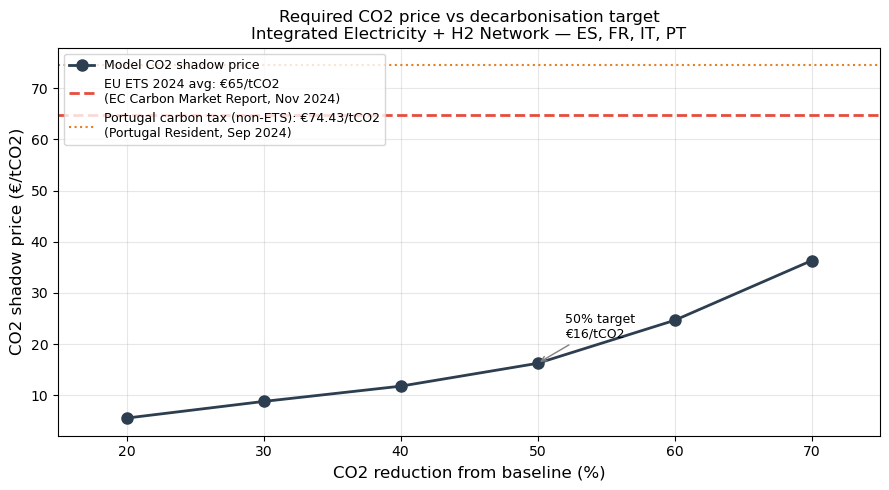

Saved: Plots/IH2_CO2_ShadowPrice.png


In [25]:

# --- Step 5: Display results ---
co2_price = result_co2.co2_shadow_price
EU_ETS_2024 = 64.74   # €/tCO2 — EC Carbon Market Report, Nov 2024

print("\n" + "="*60)
print("CO2 PRICE ANALYSIS")
print("="*60)
print(f"  Model CO2 shadow price  : €{co2_price:.2f}/tCO2")
print(f"  EU ETS 2024 average     : €{EU_ETS_2024:.2f}/tCO2")
print(f"  Ratio (model / ETS)     : {co2_price / EU_ETS_2024:.2f}x")

# --- Step 6: Sweep over multiple targets and plot shadow price curve ---
print("\nRunning sweep over CO2 reduction targets (20%, 30%, 40%, 50%, 60%, 70%)...")
sweep_df = sweep_co2_targets(
    data=data_integrated_h2,
    baseline_co2=baseline_co2,
    reductions=[0.20, 0.30, 0.40, 0.50, 0.60, 0.70],
    **_opt_kwargs,
)
print("\nSweep results:")
print(sweep_df.to_string(index=False))


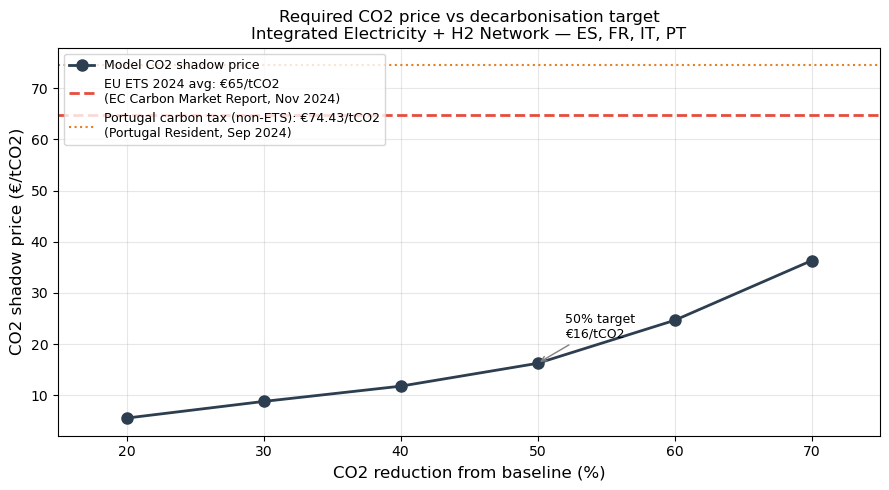

Saved: Plots/IH2_CO2_ShadowPrice.png


In [26]:

# --- Step 7: Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sweep_df["reduction_pct"], sweep_df["shadow_price_EUR_tCO2"],
        'o-', color='#2c3e50', lw=2, ms=8, label='Model CO2 shadow price')

# Reference lines
ax.axhline(EU_ETS_2024, color='#e74c3c', lw=2, ls='--',
           label=f'EU ETS 2024 avg: €{EU_ETS_2024:.0f}/tCO2\n(EC Carbon Market Report, Nov 2024)')
ax.axhline(74.43, color='#e67e22', lw=1.5, ls=':',
           label='Portugal carbon tax (non-ETS): €74.43/tCO2\n(Portugal Resident, Sep 2024)')

# Highlight the 50% target
if co2_price is not None:
    ax.annotate(f"50% target\n€{co2_price:.0f}/tCO2",
                xy=(50, co2_price), xytext=(52, co2_price + 5),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel("CO2 reduction from baseline (%)", fontsize=12)
ax.set_ylabel("CO2 shadow price (€/tCO2)", fontsize=12)
ax.set_title("Required CO2 price vs decarbonisation target\n"
             "Integrated Electricity + H2 Network — ES, FR, IT, PT", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(15, 75)

plt.tight_layout()
plt.savefig("Plots/IH2_CO2_ShadowPrice.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Plots/IH2_CO2_ShadowPrice.png")